# Exploratory Data Analysis: Indonesian News Dataset

Analysis of 5 CSV files containing Indonesian news articles across different categories:
- Technology
- Politics
- Health
- Sport
- Education

**Schema:** `id`, `source`, `date`, `title`, `Label`, `url`

## 1. Load Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
import warnings

In [2]:
files = {
    'Technology': 'data/technology.csv',
    'Politics': 'data/politic.csv',
    'Health': 'data/health.csv',
    'Sport': 'data/sport.csv',
    'Education': 'data/education.csv'
}

datasets = {}
for category, filepath in files.items():
    try:
        df = pd.read_csv(filepath)
        datasets[category] = df
        print(f"✓ {category}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    except Exception as e:
        print(f"✗ Error loading {category}: {e}")

print(f"\nTotal datasets loaded: {len(datasets)}")

✓ Technology: 1,000 rows × 6 columns
✓ Politics: 1,000 rows × 6 columns
✓ Health: 1,000 rows × 6 columns
✓ Sport: 1,000 rows × 6 columns
✓ Education: 1,000 rows × 6 columns

Total datasets loaded: 5


## 2. Setup and Imports

In [3]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# ---------------------------------------------------------------
# UNIFIED GLOBAL STYLE (single source of truth for the whole notebook)
# ---------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Fixed label mapping and colors -> a class is ALWAYS the same color
LABEL_NAMES = {0: "Non-Clickbait", 1: "Clickbait"}
LABEL_COLORS = {"Non-Clickbait": "#4C72B0", "Clickbait": "#DD8452"}
LABEL_ORDER = ["Non-Clickbait", "Clickbait"]
# Numeric-keyed label colors for cells that group by the raw 0/1 Label
LABEL_COLORS_NUM = {0: LABEL_COLORS["Non-Clickbait"], 1: LABEL_COLORS["Clickbait"]}

# Stable per-domain palette
DOMAINS = list(datasets.keys()) if "datasets" in dir() else []
DOMAIN_COLORS = dict(zip(DOMAINS, sns.color_palette("deep", len(DOMAINS)))) if DOMAINS else {}


def annotate_bars(ax, fmt="{:.0f}", fontsize=10, padding=3):
    """Write the height of each vertical bar on top of it."""
    for p in ax.patches:
        h = p.get_height()
        if not np.isfinite(h) or h == 0:
            continue
        ax.annotate(fmt.format(h),
                    (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=fontsize,
                    xytext=(0, padding), textcoords="offset points")


def annotate_barh(ax, fmt="{:.1f}%", fontsize=10, padding=3):
    """Write the width of each horizontal bar at its end."""
    for p in ax.patches:
        w = p.get_width()
        if not np.isfinite(w) or w == 0:
            continue
        ax.annotate(fmt.format(w),
                    (w, p.get_y() + p.get_height() / 2),
                    ha="left", va="center", fontsize=fontsize,
                    xytext=(padding, 0), textcoords="offset points")


def show_table(frame, title):
    """Print a titled exact-metrics table right before its paired chart."""
    print("\n" + "=" * 72 + "\n" + title + "\n" + "=" * 72)
    display(frame)


print("Setup complete - unified style, palette & helpers loaded")

Setup complete - unified style, palette & helpers loaded


## 3. Dataset Overview

In [4]:
overview_data = []
for category, df in datasets.items():
    overview_data.append({
        'Category': category,
        'Rows': f"{df.shape[0]:,}",
        'Columns': df.shape[1],
        'Memory (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        'Missing Values': df.isnull().sum().sum(),
        'Duplicate Rows': df.duplicated().sum()
    })

overview_df = pd.DataFrame(overview_data)
print("\nDataset Overview Summary:")
display(overview_df)


Dataset Overview Summary:


,Category,Rows,Columns,Memory (MB),Missing Values,Duplicate Rows
0,Technology,"1,000",6,0.38,0,0
1,Politics,"1,000",6,0.40,0,0
2,Health,"1,000",6,0.39,0,0
3,Sport,"1,000",6,0.39,0,0
4,Education,"1,000",6,0.40,0,0


### Sample Data Preview

In [5]:
for category, df in datasets.items():
    print(f"\n{category} - Sample (first 3 rows):")
    display(df.head(3))


Technology - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-05,"Gandeng Nvidia dan Google, Apple Berencana Rilis Siri Generasi Baru",0,https://www.cnnindonesia.com/teknologi/20260605142602-185-1365742/gandeng-nvidia-dan-google-appl...
1,2,CNN Indonesia,2026-06-05,"Sindikat Online Scams Internasional Ditangkap, Jutaan Akun Diblokir",0,https://www.cnnindonesia.com/teknologi/20260605124822-185-1365685/sindikat-online-scams-internas...
2,3,CNN Indonesia,2026-06-05,"Masa Depan AI di Persimpangan, Kemajuan vs Ancaman Krisis Air",0,https://www.cnnindonesia.com/teknologi/20260605133646-641-1365706/masa-depan-ai-di-persimpangan-...



Politics - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-06,Karantina Lampung Gagalkan Penyelundupan 172 Burung Ilegal,0,https://www.cnnindonesia.com/nasional/20260606150717-20-1366112/karantina-lampung-gagalkan-penye...
1,2,CNN Indonesia,2026-06-06,"KY Terima 592 Aduan Pelanggaran Etik Hakim, Lima Diberhentikan",0,https://www.cnnindonesia.com/nasional/20260606181016-12-1366168/ky-terima-592-aduan-pelanggaran-...
2,3,CNN Indonesia,2026-06-06,"Jelang Muktamar, PBNU Gelar Munas dan Konbes NU di Kediri 20-21 Juni",0,https://www.cnnindonesia.com/nasional/20260606144140-20-1366095/jelang-muktamar-pbnu-gelar-munas...



Health - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-05,"7 Ciri Anak Percaya Diri, Bisa Terlihat dari Perilakunya Sehari-hari",0,https://www.cnnindonesia.com/gaya-hidup/20260605111435-284-1365657/7-ciri-anak-percaya-diri-bisa...
1,2,CNN Indonesia,2026-06-03,10 Destinasi Wisata Paling Digemari di Asia Tenggara,0,https://www.cnnindonesia.com/gaya-hidup/20260603195514-269-1365085/10-destinasi-wisata-paling-di...
2,3,CNN Indonesia,2026-06-06,"Kasus Ebola di Afrika Tengah Tembus 471, WHO Waspada Ledakan Wabah",0,https://www.cnnindonesia.com/gaya-hidup/20260606192658-255-1366183/kasus-ebola-di-afrika-tengah-...



Sport - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,CNN Indonesia,2026-06-07,"Hasil Uji Coba Jelang Piala Dunia: Messi Tak Main, Argentina Menang",0,https://www.cnnindonesia.com/olahraga/20260607090917-142-1366236/hasil-uji-coba-jelang-piala-dun...
1,2,CNN Indonesia,2026-06-07,"Veda Ega Kena Long Lap Penalty, Tak Patah Arang di Moto3 Hungaria",0,https://www.cnnindonesia.com/olahraga/20260607082253-156-1366233/veda-ega-kena-long-lap-penalty-...
2,3,CNN Indonesia,2026-06-07,Final Indonesia Open 2026: Kans Jonatan Ikuti Jejak Kevin/Marcus,0,https://www.cnnindonesia.com/olahraga/20260607080842-170-1366232/final-indonesia-open-2026-kans-...



Education - Sample (first 3 rows):


,id,source,date,title,Label,url
0,1,Tribun News,2026-06-06,"Pesantren Capai 42 Ribu, Kemenag: Jumlah Santri Nasional Tak Alami Penurunan Signifikan",0,https://www.tribunnews.com/nasional/7838729/pesantren-capai-42-ribu-kemenag-jumlah-santri-nasion...
1,2,Tribun News,2026-04-06,Penyanyi Ary Kirana Soroti Pentingnya Pendidikan Usia Dini,0,https://www.tribunnews.com/seleb/7838151/penyanyi-ary-kirana-soroti-pentingnya-pendidikan-usia-dini
2,3,Tribun News,2026-05-29,Kuasa Hukum Sebut Pledoi Nadiem Akan Ungkap Keberhasilan Sistem Pendidikan,0,https://www.tribunnews.com/nasional/7835460/kuasa-hukum-sebut-pledoi-nadiem-akan-ungkap-keberhas...


### Data Types

In [6]:
for category, df in datasets.items():
    print(f"\n{category}:")
    print(df.dtypes.to_string())
    print(f"Columns: {list(df.columns)}")


Technology:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Politics:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Health:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Sport:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']

Education:
id         int64
source    object
date      object
title     object
Label      int64
url       object
Columns: ['id', 'source', 'date', 'title', 'Label', 'url']


## 4. Column-Level Analysis
### 4.1 Source Distribution


Technology - Source Distribution:


,Source,Count,Percentage
0,Detik,708,70.8
1,Kompas,255,25.5
2,CNN Indonesia,37,3.7


Unique sources: 3

Politics - Source Distribution:


,Source,Count,Percentage
0,CNN Indonesia,580,58.0
1,Kompas,295,29.5
2,Kompas Politik,80,8.0
3,Kompas Nasional,44,4.4
4,Kompas Internasional,1,0.1


Unique sources: 5

Health - Source Distribution:


...

Unique sources: 3

Sport - Source Distribution:


,Source,Count,Percentage
0,Kompas,624,62.4
1,Detik,326,32.6
2,CNN Indonesia,50,5.0


Unique sources: 3

Education - Source Distribution:


,Source,Count,Percentage
0,Detik Edu,709,70.9
1,Tribun News,190,19.0
2,Kompas,101,10.1


Unique sources: 3


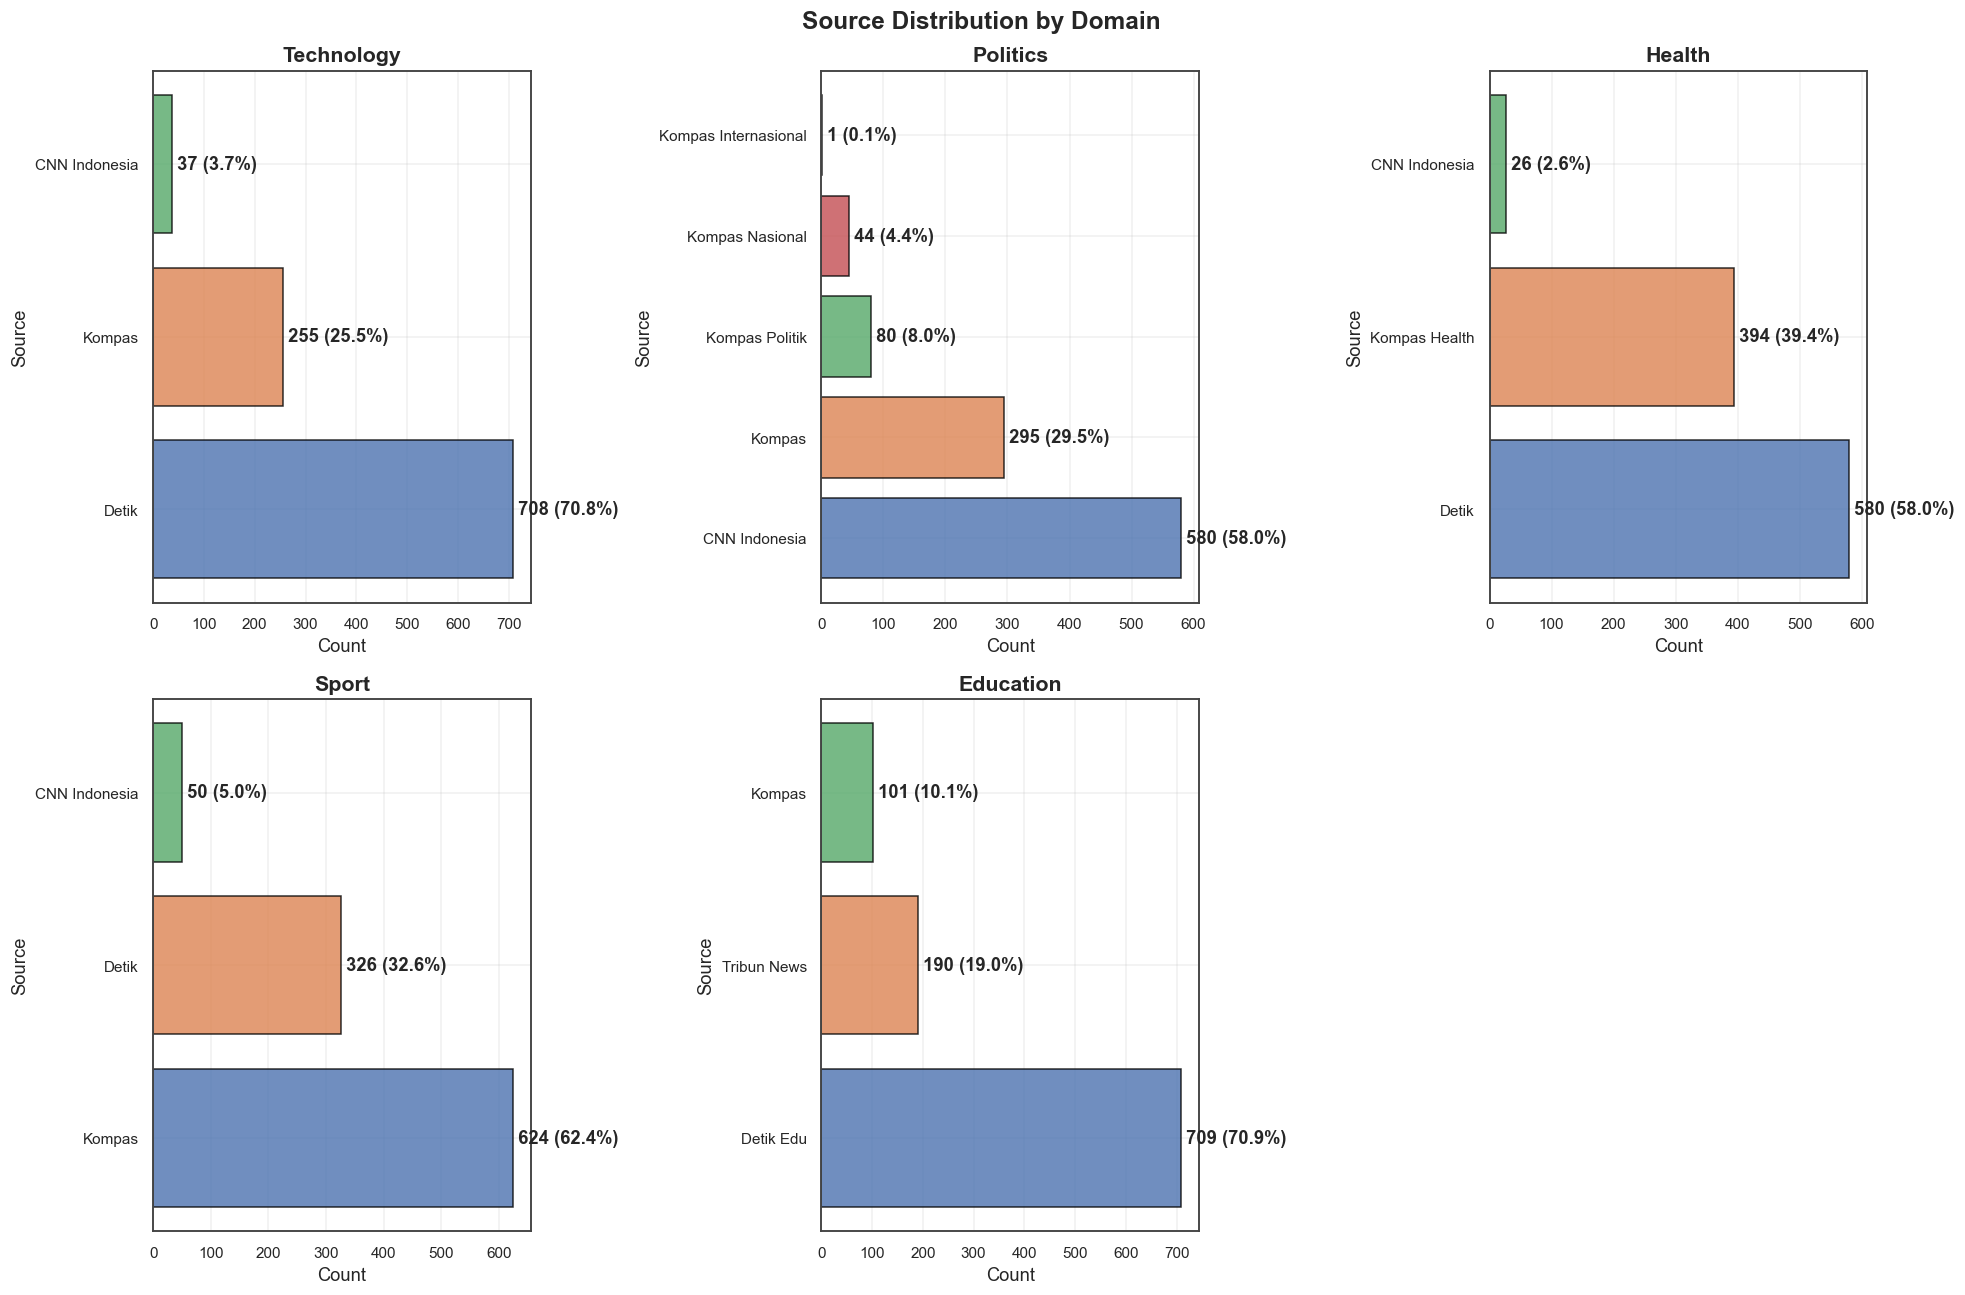

In [36]:
# ===============TABLE===============
for category, df in datasets.items():
    if 'source' in df.columns:
        print(f"\n{category} - Source Distribution:")
        source_counts = df['source'].value_counts()
        source_pct = (source_counts / len(df) * 100).round(2)
        source_df = pd.DataFrame({
            'Source': source_counts.index,
            'Count': source_counts.values,
            'Percentage': source_pct.values
        })
        display(source_df)
        print(f"Unique sources: {df['source'].nunique()}")


# ===============PLOT ===============
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (category, df) in enumerate(datasets.items()):

    if 'source' not in df.columns:
        axes[idx].axis('off')
        continue

    # Same calculation as table
    source_counts = df['source'].value_counts()
    source_pct = (source_counts / len(df) * 100).round(2)

    colors = sns.color_palette("deep", len(source_counts))

    axes[idx].barh(
        source_counts.index,
        source_counts.values,
        color=colors,
        edgecolor='black',
        alpha=0.8
    )

    axes[idx].set_title(category, fontweight='bold')
    axes[idx].set_xlabel('Count')
    axes[idx].set_ylabel('Source')
    axes[idx].grid(axis='x', alpha=0.3)

    # Count + percentage
    for i, (count, pct) in enumerate(
        zip(source_counts.values, source_pct.values)
    ):
        axes[idx].text(
            count,
            i,
            f' {count:,} ({pct:.1f}%)',
            va='center',
            fontweight='bold'
        )

# Hide unused subplot
for ax in axes[len(datasets):]:
    ax.axis('off')

plt.suptitle(
    'Source Distribution by Domain',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 4.2 Label Distribution

In [8]:
# # ===============TABLE===============
# label_data = []

# print("==========Class Imbalance Ratio==========")

# for category, df in datasets.items():
#     if 'Label' not in df.columns:
#         continue

#     label_counts = df['Label'].value_counts().sort_index()
#     label_pct = (label_counts / len(df) * 100).round(2)

#     for label in label_counts.index:
#         label_data.append({
#             'Domain': category,
#             'Label': label,
#             'Count': label_counts[label],
#             'Percentage': label_pct[label]
#         })

#     if len(label_counts) == 2:
#         imbalance_ratio = label_counts.max() / label_counts.min()
#         print(f"{category}: {imbalance_ratio:.2f} : 1")

# # Combined table
# label_df = pd.DataFrame(label_data)
# display(label_df)      


# # ===============PLOT===============
# plot_df = label_df.pivot(
#     index='Domain',
#     columns='Label',
#     values='Percentage'
# )

# ax = plot_df.plot(
#     kind='bar',
#     stacked=True,
#     figsize=(10, 6),
#     width=0.8,
#     color=[LABEL_COLORS_NUM[c] for c in plot_df.columns]
# )

# for container in ax.containers:
#     ax.bar_label(
#         container,
#         fmt='%.1f%%',
#         label_type='center',
#         fontsize=9
#     )

# plt.title('Label Distribution Across Domains')
# plt.xlabel('Domain')
# plt.ylabel('Distribution in Percentage (%)')

# plt.ylim(0, 100)

# plt.legend(
#     LABEL_ORDER,
#     title='Label',
#     loc='upper center',
#     bbox_to_anchor=(0.5, -0.08),
#     ncol=2,
#     frameon=False
# )

# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

### 4.3 Date Range Analysis

In [9]:
for category, df in datasets.items():
    if 'date' in df.columns:
        print(f"\n{category} - Date Analysis:")
        df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
        valid_dates = df['date_parsed'].dropna()

        if len(valid_dates) > 0:
            print(f"Date Range: {valid_dates.min().date()} to {valid_dates.max().date()}")
            print(f"Total Days Span: {(valid_dates.max() - valid_dates.min()).days} days")
            print(f"Valid Dates: {len(valid_dates):,} ({len(valid_dates)/len(df)*100:.1f}%)")
            print(f"Invalid/Missing: {len(df) - len(valid_dates):,}")

            df['year'] = df['date_parsed'].dt.year
            year_dist = df['year'].value_counts().sort_index()
            print("\nYear Distribution:")
            for year, count in year_dist.items():
                if pd.notna(year):
                    print(f"  {int(year)}: {count:,} articles")


Technology - Date Analysis:
Date Range: 2023-06-10 to 2026-06-06
Total Days Span: 1092 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2023: 21 articles
  2024: 40 articles
  2025: 65 articles
  2026: 874 articles

Politics - Date Analysis:
Date Range: 2026-02-24 to 2026-06-07
Total Days Span: 103 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2026: 1,000 articles

Health - Date Analysis:
Date Range: 2023-07-23 to 2026-06-08
Total Days Span: 1051 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2023: 80 articles
  2024: 107 articles
  2025: 90 articles
  2026: 723 articles

Sport - Date Analysis:
Date Range: 2024-11-21 to 2026-06-07
Total Days Span: 563 days
Valid Dates: 1,000 (100.0%)
Invalid/Missing: 0

Year Distribution:
  2024: 12 articles
  2025: 112 articles
  2026: 876 articles

Education - Date Analysis:
Date Range: 2025-01-11 to 2026-12-05
Total Days Span: 693 days
Valid Dates: 1,000 (100.0%)
Invali

### 4.5 URL Domain Analysis

In [10]:
# from urllib.parse import urlparse

# # ===============URL DOMAIN DATA===============
# url_domain_data = []
# print("==========URL Domain Analysis==========")

# for category, df in datasets.items():
#     if 'url' not in df.columns:
#         continue

#     # Extract URL domain
#     url_domains = df['url'].apply(
#         lambda x: urlparse(str(x)).netloc if pd.notna(x) else None
#     )

#     # Remove empty domains
#     url_domains = url_domains[
#         url_domains.notna() &
#         (url_domains != '')
#     ]

#     domain_counts = url_domains.value_counts().head(10)
#     print(f"\n{category} - URL Domain Analysis:")
#     print(f"Total unique domains: {url_domains.nunique()}")

#     for domain, count in domain_counts.items():
#         percentage = count / len(df) * 100
#         url_domain_data.append({
#             'Dataset_Domain': category,
#             'URL_Domain': domain,
#             'Count': count,
#             'Percentage': percentage
#         })

# url_domain_df = pd.DataFrame(url_domain_data)
# display(url_domain_df)


# # ===============PLOT: URL DOMAIN DISTRIBUTION===============

# domains = url_domain_df['Dataset_Domain'].unique()

# fig, axes = plt.subplots(
#     nrows=len(domains),
#     ncols=1,
#     figsize=(10, 4 * len(domains))
# )

# for ax, category in zip(axes, domains):
#     subset = url_domain_df[
#         url_domain_df['Dataset_Domain'] == category
#     ].sort_values('Percentage')

#     ax.barh(
#         subset['URL_Domain'],
#         subset['Percentage']
#     )

#     ax.set_title(category)
#     ax.set_xlabel('Percentage of Articles (%)')
#     ax.set_ylabel('URL Domain')

#     # Add percentage labels
#     for i, value in enumerate(subset['Percentage']):
#         ax.text(
#             value + 0.2,
#             i,
#             f'{value:.1f}%',
#             va='center',
#             fontsize=9
#         )

# fig.suptitle(
#     'Top URL Domains by Dataset Domain',
#     fontsize=15,
#     y=1.002
# )

# plt.tight_layout()
# plt.show()

## 5. Data Quality Checks
### 5.1 Missing Values

,Domain,Column,Missing_Count,Missing_Percentage
0,Technology,id,0,0.0
1,Technology,source,0,0.0
2,Technology,date,0,0.0
3,Technology,title,0,0.0
4,Technology,Label,0,0.0
5,Technology,url,0,0.0
6,Technology,date_parsed,0,0.0
7,Technology,year,0,0.0
8,Politics,id,0,0.0
9,Politics,source,0,0.0


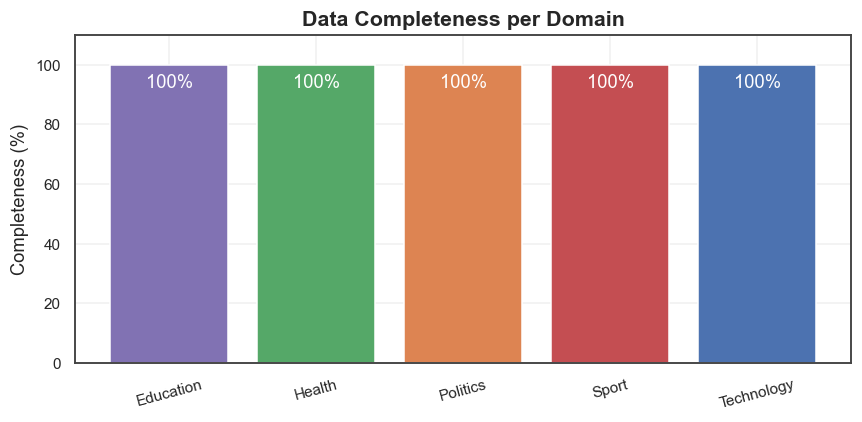

In [11]:
# ===============MISSING VALUE DATA===============

missing_data = []

for category, df in datasets.items():

    missing = df.isnull().sum()

    for column, count in missing.items():

        missing_data.append({
            'Domain': category,
            'Column': column,
            'Missing_Count': count,
            'Missing_Percentage': count / len(df) * 100
        })

missing_df = pd.DataFrame(missing_data)
display(missing_df)


# ===============PLOT: DATA COMPLETENESS===============

completeness = (
    missing_df
    .groupby('Domain')['Missing_Percentage']
    .mean()
    .rsub(100)
)

plt.figure(figsize=(8, 4))

bars = plt.bar(
    completeness.index,
    completeness.values,
    color=[
        DOMAIN_COLORS.get(d, '#4C72B0')
        for d in completeness.index
    ]
)

for bar, value in zip(bars, completeness.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value - 3,
        f'{value:.0f}%',
        ha='center',
        va='top',
        color='white'
    )

plt.ylabel('Completeness (%)')
plt.title('Data Completeness per Domain')
plt.ylim(0, 110)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 5.2 Duplicate Analysis


Duplicate Summary Across All Datasets:


,Category,Total Rows,Duplicate IDs,Duplicate Titles,Duplicate URLs,Duplicate Rows
0,Technology,1000,0,0,0,0
1,Politics,1000,0,0,0,0
2,Health,1000,0,0,0,0
3,Sport,1000,0,0,0,0
4,Education,1000,0,0,0,0


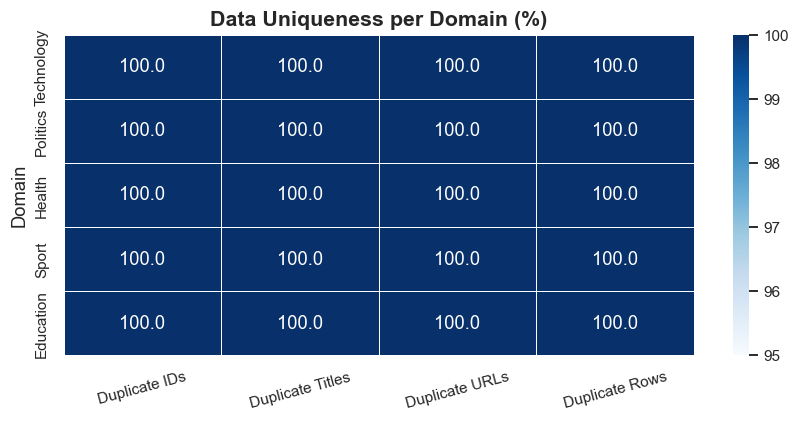

In [12]:
# ===============TABLE===============
dup_summary = []
for category, df in datasets.items():
    dup_data = {'Category': category, 'Total Rows': len(df)}

    if 'id' in df.columns:
        dup_data['Duplicate IDs'] = df['id'].duplicated().sum()
    if 'title' in df.columns:
        dup_data['Duplicate Titles'] = df['title'].duplicated().sum()
    if 'url' in df.columns:
        dup_data['Duplicate URLs'] = df['url'].duplicated().sum()

    dup_data['Duplicate Rows'] = df.duplicated().sum()
    dup_summary.append(dup_data)

dup_df = pd.DataFrame(dup_summary)
print("\nDuplicate Summary Across All Datasets:")
display(dup_df)


# ===============PLOT: DATA UNIQUENESS===============

metrics = [
    'Duplicate IDs',
    'Duplicate Titles',
    'Duplicate URLs',
    'Duplicate Rows'
]

metrics = [m for m in metrics if m in dup_df.columns]

uniqueness = dup_df[['Category'] + metrics].copy()

for metric in metrics:
    uniqueness[metric] = (
        100 - uniqueness[metric] / dup_df['Total Rows'] * 100
    )

uniqueness = uniqueness.set_index('Category')

plt.figure(figsize=(8, 4))

sns.heatmap(
    uniqueness,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=95,
    vmax=100,
    linewidths=0.5,
    linecolor='white'
)

plt.title('Data Uniqueness per Domain (%)')
plt.xlabel('')
plt.ylabel('Domain')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 5.3 Invalid Dates

In [13]:
for category, df in datasets.items():
    if 'date' in df.columns:
        print(f"\n{category} - Date Validation:")
        df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
        invalid_dates = df[df['date_parsed'].isna()]

        print(f"Valid Dates: {len(df) - len(invalid_dates):,}")
        print(f"Invalid/Missing: {len(invalid_dates):,}")

        if len(invalid_dates) > 0:
            print("\nSample Invalid Dates:")
            display(invalid_dates[['id', 'date']].head())


Technology - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Politics - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Health - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Sport - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0

Education - Date Validation:
Valid Dates: 1,000
Invalid/Missing: 0


### 5.4 Class Imbalance Summary

,Domain,Label,Count,Percentage,Imbalance Ratio,Status
0,Technology,0,772,77.2,3.39:1,Imbalanced
1,Technology,1,228,22.8,3.39:1,Imbalanced
2,Politics,0,813,81.3,4.35:1,Imbalanced
3,Politics,1,187,18.7,4.35:1,Imbalanced
4,Health,0,624,62.4,1.66:1,Imbalanced
5,Health,1,376,37.6,1.66:1,Imbalanced
6,Sport,0,763,76.3,3.22:1,Imbalanced
7,Sport,1,237,23.7,3.22:1,Imbalanced
8,Education,0,650,65.0,1.86:1,Imbalanced
9,Education,1,350,35.0,1.86:1,Imbalanced


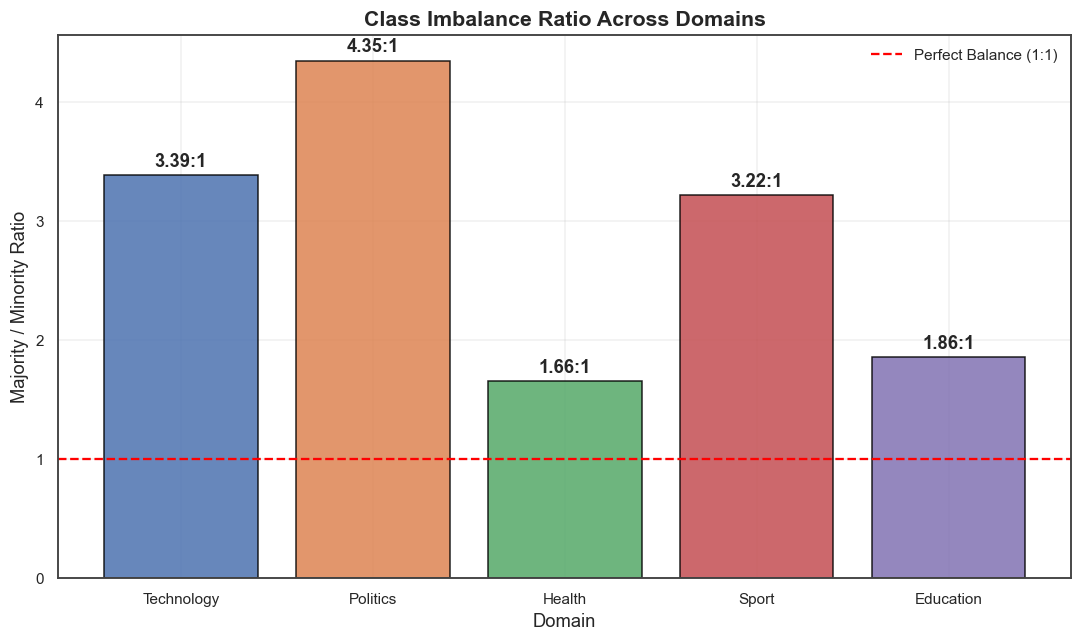

In [14]:
# =============== TABLE ===============
label_data = []

for category, df in datasets.items():
    if 'Label' not in df.columns:
        continue

    counts = df['Label'].value_counts().sort_index()
    percentages = (counts / len(df) * 100).round(2)

    if len(counts) >= 2:
        ratio = counts.max() / counts.min()
        status = 'Balanced' if ratio < 1.5 else 'Imbalanced'
    else:
        ratio = None
        status = 'Cannot determine'

    for label in counts.index:
        label_data.append({
            'Domain': category,
            'Label': label,
            'Count': counts[label],
            'Percentage': percentages[label],
            'Imbalance Ratio': ratio,
            'Status': status
        })

label_df = pd.DataFrame(label_data)

display_df = label_df.copy()
display_df['Imbalance Ratio'] = display_df['Imbalance Ratio'].apply(
    lambda x: f'{x:.2f}:1' if pd.notna(x) else None
)

display(display_df)


# =============== PLOT ===============
imbalance_plot = (
    label_df[['Domain', 'Imbalance Ratio']]
    .drop_duplicates()
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    imbalance_plot['Domain'],
    imbalance_plot['Imbalance Ratio'],
    color=[
        DOMAIN_COLORS.get(d, '#4C72B0')
        for d in imbalance_plot['Domain']
    ],
    edgecolor='black',
    alpha=0.85
)

ax.axhline(
    1,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Perfect Balance (1:1)'
)

ax.bar_label(
    bars,
    labels=[f'{v:.2f}:1' for v in imbalance_plot['Imbalance Ratio']],
    padding=3,
    fontweight='bold'
)

ax.set(
    title='Class Imbalance Ratio Across Domains',
    xlabel='Domain',
    ylabel='Majority / Minority Ratio'
)

ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visualizations
### 6.1 Label Distribution

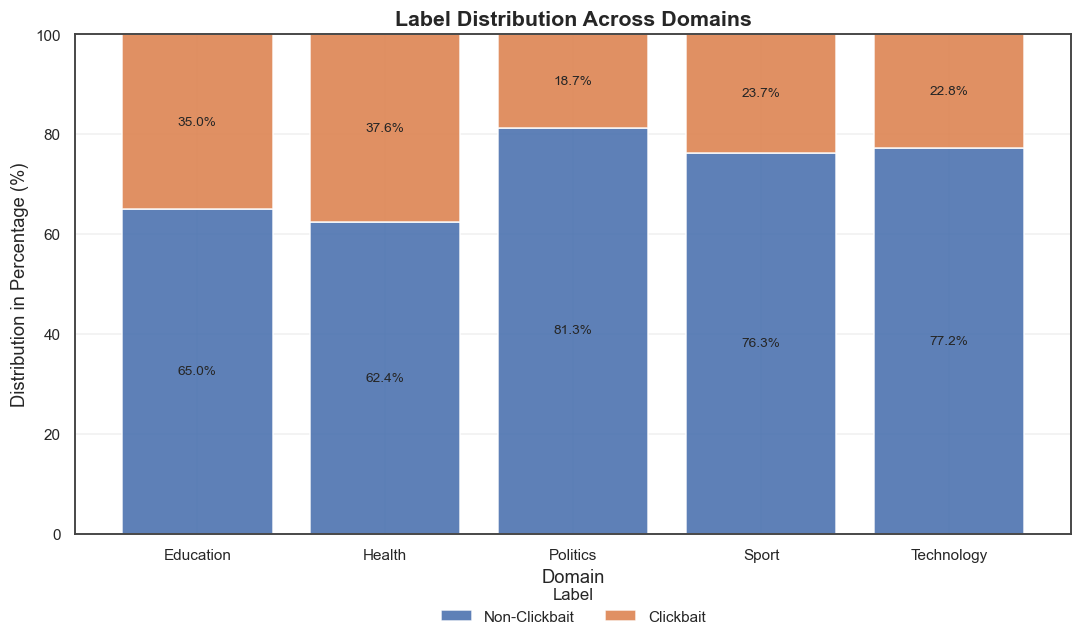

In [15]:

# =============== LABEL DISTRIBUTION ===============

plot_df = label_df.pivot(
    index='Domain',
    columns='Label',
    values='Percentage'
)

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    width=0.8,
    color=[LABEL_COLORS_NUM[c] for c in plot_df.columns],
    alpha=0.9
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9
    )

ax.set(
    title='Label Distribution Across Domains',
    xlabel='Domain',
    ylabel='Distribution in Percentage (%)',
    ylim=(0, 100)
)

ax.legend(
    [LABEL_NAMES[c] for c in plot_df.columns],
    title='Label',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# axes = axes.flatten()

# for idx, (category, df) in enumerate(datasets.items()):
#     if 'Label' in df.columns:
#         label_counts = df['Label'].value_counts().sort_index()
#         axes[idx].bar(label_counts.index.astype(str), label_counts.values,
#                      color=[LABEL_COLORS_NUM[i] for i in label_counts.index], edgecolor='black', alpha=0.8)
#         axes[idx].set_title(f'{category}\n(n={len(df):,})', fontweight='bold')
#         axes[idx].set_xlabel('Label')
#         axes[idx].set_ylabel('Count')
#         axes[idx].grid(axis='y', alpha=0.3)

#         for i, v in enumerate(label_counts.values):
#             axes[idx].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# axes[-1].axis('off')
# plt.suptitle('Label Distribution Across All Datasets', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.show()

### 6.2 Source Distribution

In [35]:


# # ===============PLOT===============
# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# axes = axes.flatten()

# for idx, (category, df) in enumerate(datasets.items()):
#     if 'source' in df.columns:
#         source_counts = df['source'].value_counts()
#         colors = sns.color_palette("deep", len(source_counts))
#         axes[idx].barh(source_counts.index, source_counts.values, color=colors, edgecolor='black', alpha=0.8)
#         axes[idx].set_title(f'{category}', fontweight='bold')
#         axes[idx].set_xlabel('Count')
#         axes[idx].grid(axis='x', alpha=0.3)

#         for i, v in enumerate(source_counts.values):
#             axes[idx].text(v, i, f' {v:,}', va='center', fontweight='bold')

# axes[-1].axis('off')
# plt.suptitle('Source Distribution', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.show()

### 6.3 Article Count Over Time

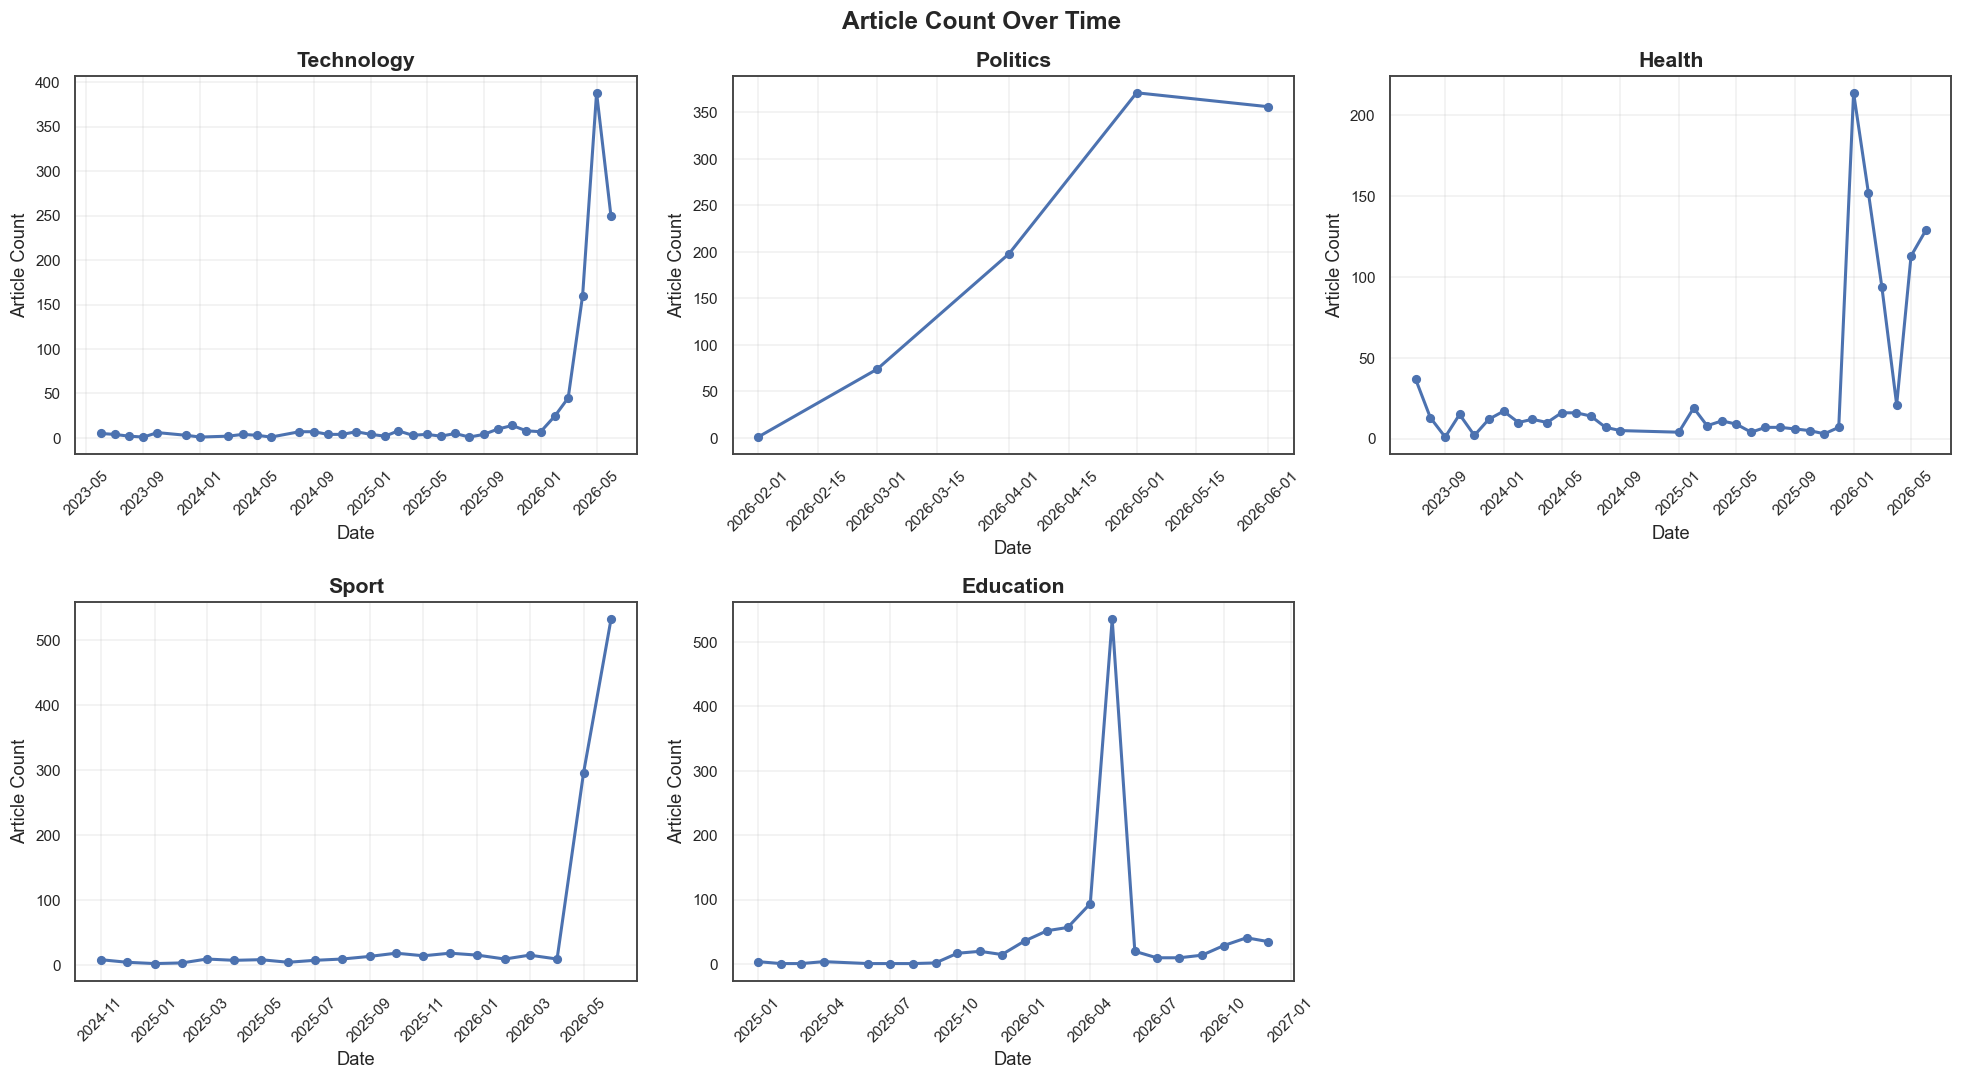

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (category, df) in enumerate(datasets.items()):
    if 'date' in df.columns:
        df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
        df['year_month'] = df['date_parsed'].dt.to_period('M')
        monthly_counts = df['year_month'].value_counts().sort_index()

        if len(monthly_counts) > 0:
            x_values = [period.to_timestamp() for period in monthly_counts.index]
            axes[idx].plot(x_values, monthly_counts.values, marker='o', linewidth=2, markersize=5)
            axes[idx].set_title(f'{category}', fontweight='bold')
            axes[idx].set_xlabel('Date')
            axes[idx].set_ylabel('Article Count')
            axes[idx].grid(True, alpha=0.3)
            axes[idx].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.suptitle('Article Count Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Title Length Distribution

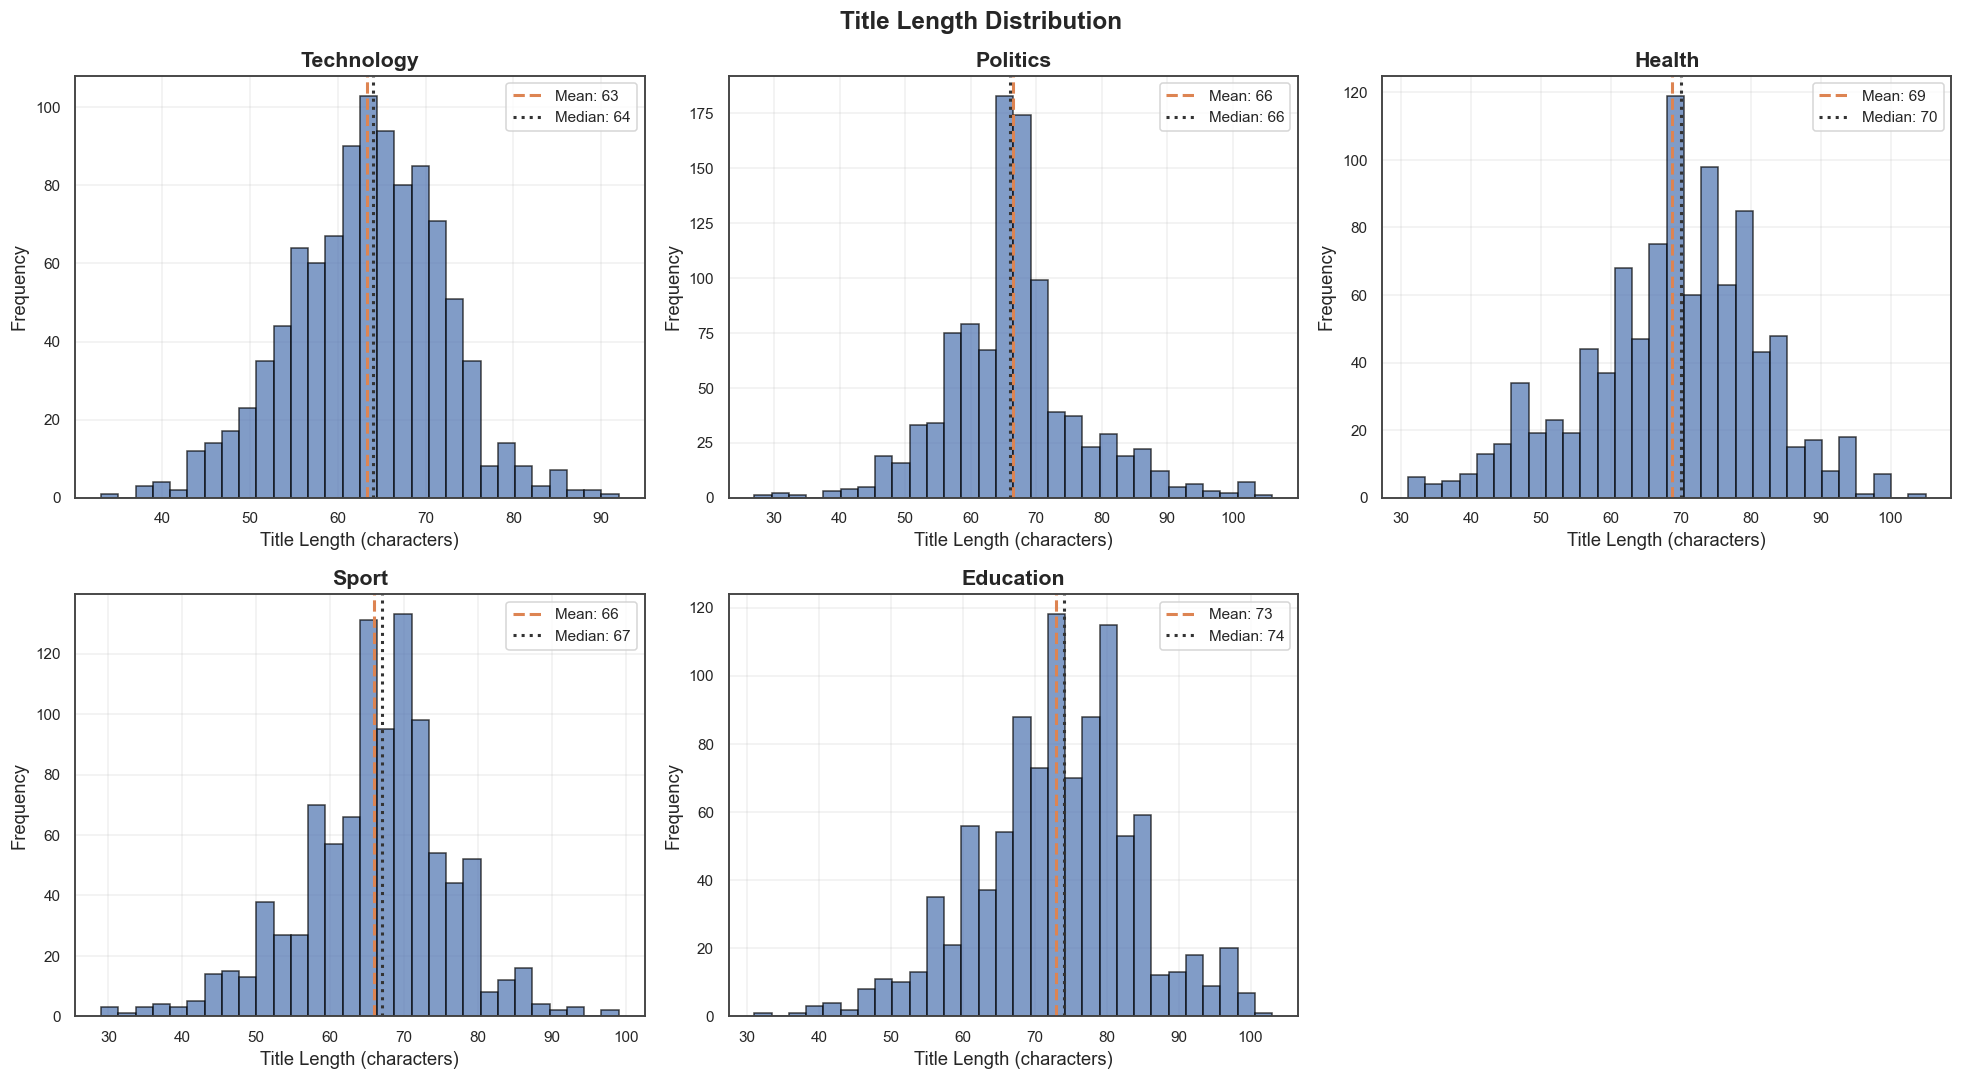

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (category, df) in enumerate(datasets.items()):
    if "title" in df.columns:
        df["title_length"] = df["title"].astype(str).str.len()

        axes[idx].hist(
            df["title_length"],
            bins=30,
            color=LABEL_COLORS["Non-Clickbait"],
            edgecolor="black",
            alpha=0.7,
        )
        axes[idx].axvline(
            df["title_length"].mean(),
            color=LABEL_COLORS["Clickbait"],
            linestyle="--",
            linewidth=2,
            label=f"Mean: {df['title_length'].mean():.0f}",
        )
        axes[idx].axvline(
            df["title_length"].median(),
            color="#333333",
            linestyle=":",
            linewidth=2,
            label=f"Median: {df['title_length'].median():.0f}",
        )
        axes[idx].set_title(f"{category}", fontweight="bold")
        axes[idx].set_xlabel("Title Length (characters)")
        axes[idx].set_ylabel("Frequency")
        axes[idx].legend()
        axes[idx].grid(axis="y", alpha=0.3)

axes[-1].axis("off")
plt.suptitle("Title Length Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.5 Top Frewuent Words by Domain and Label

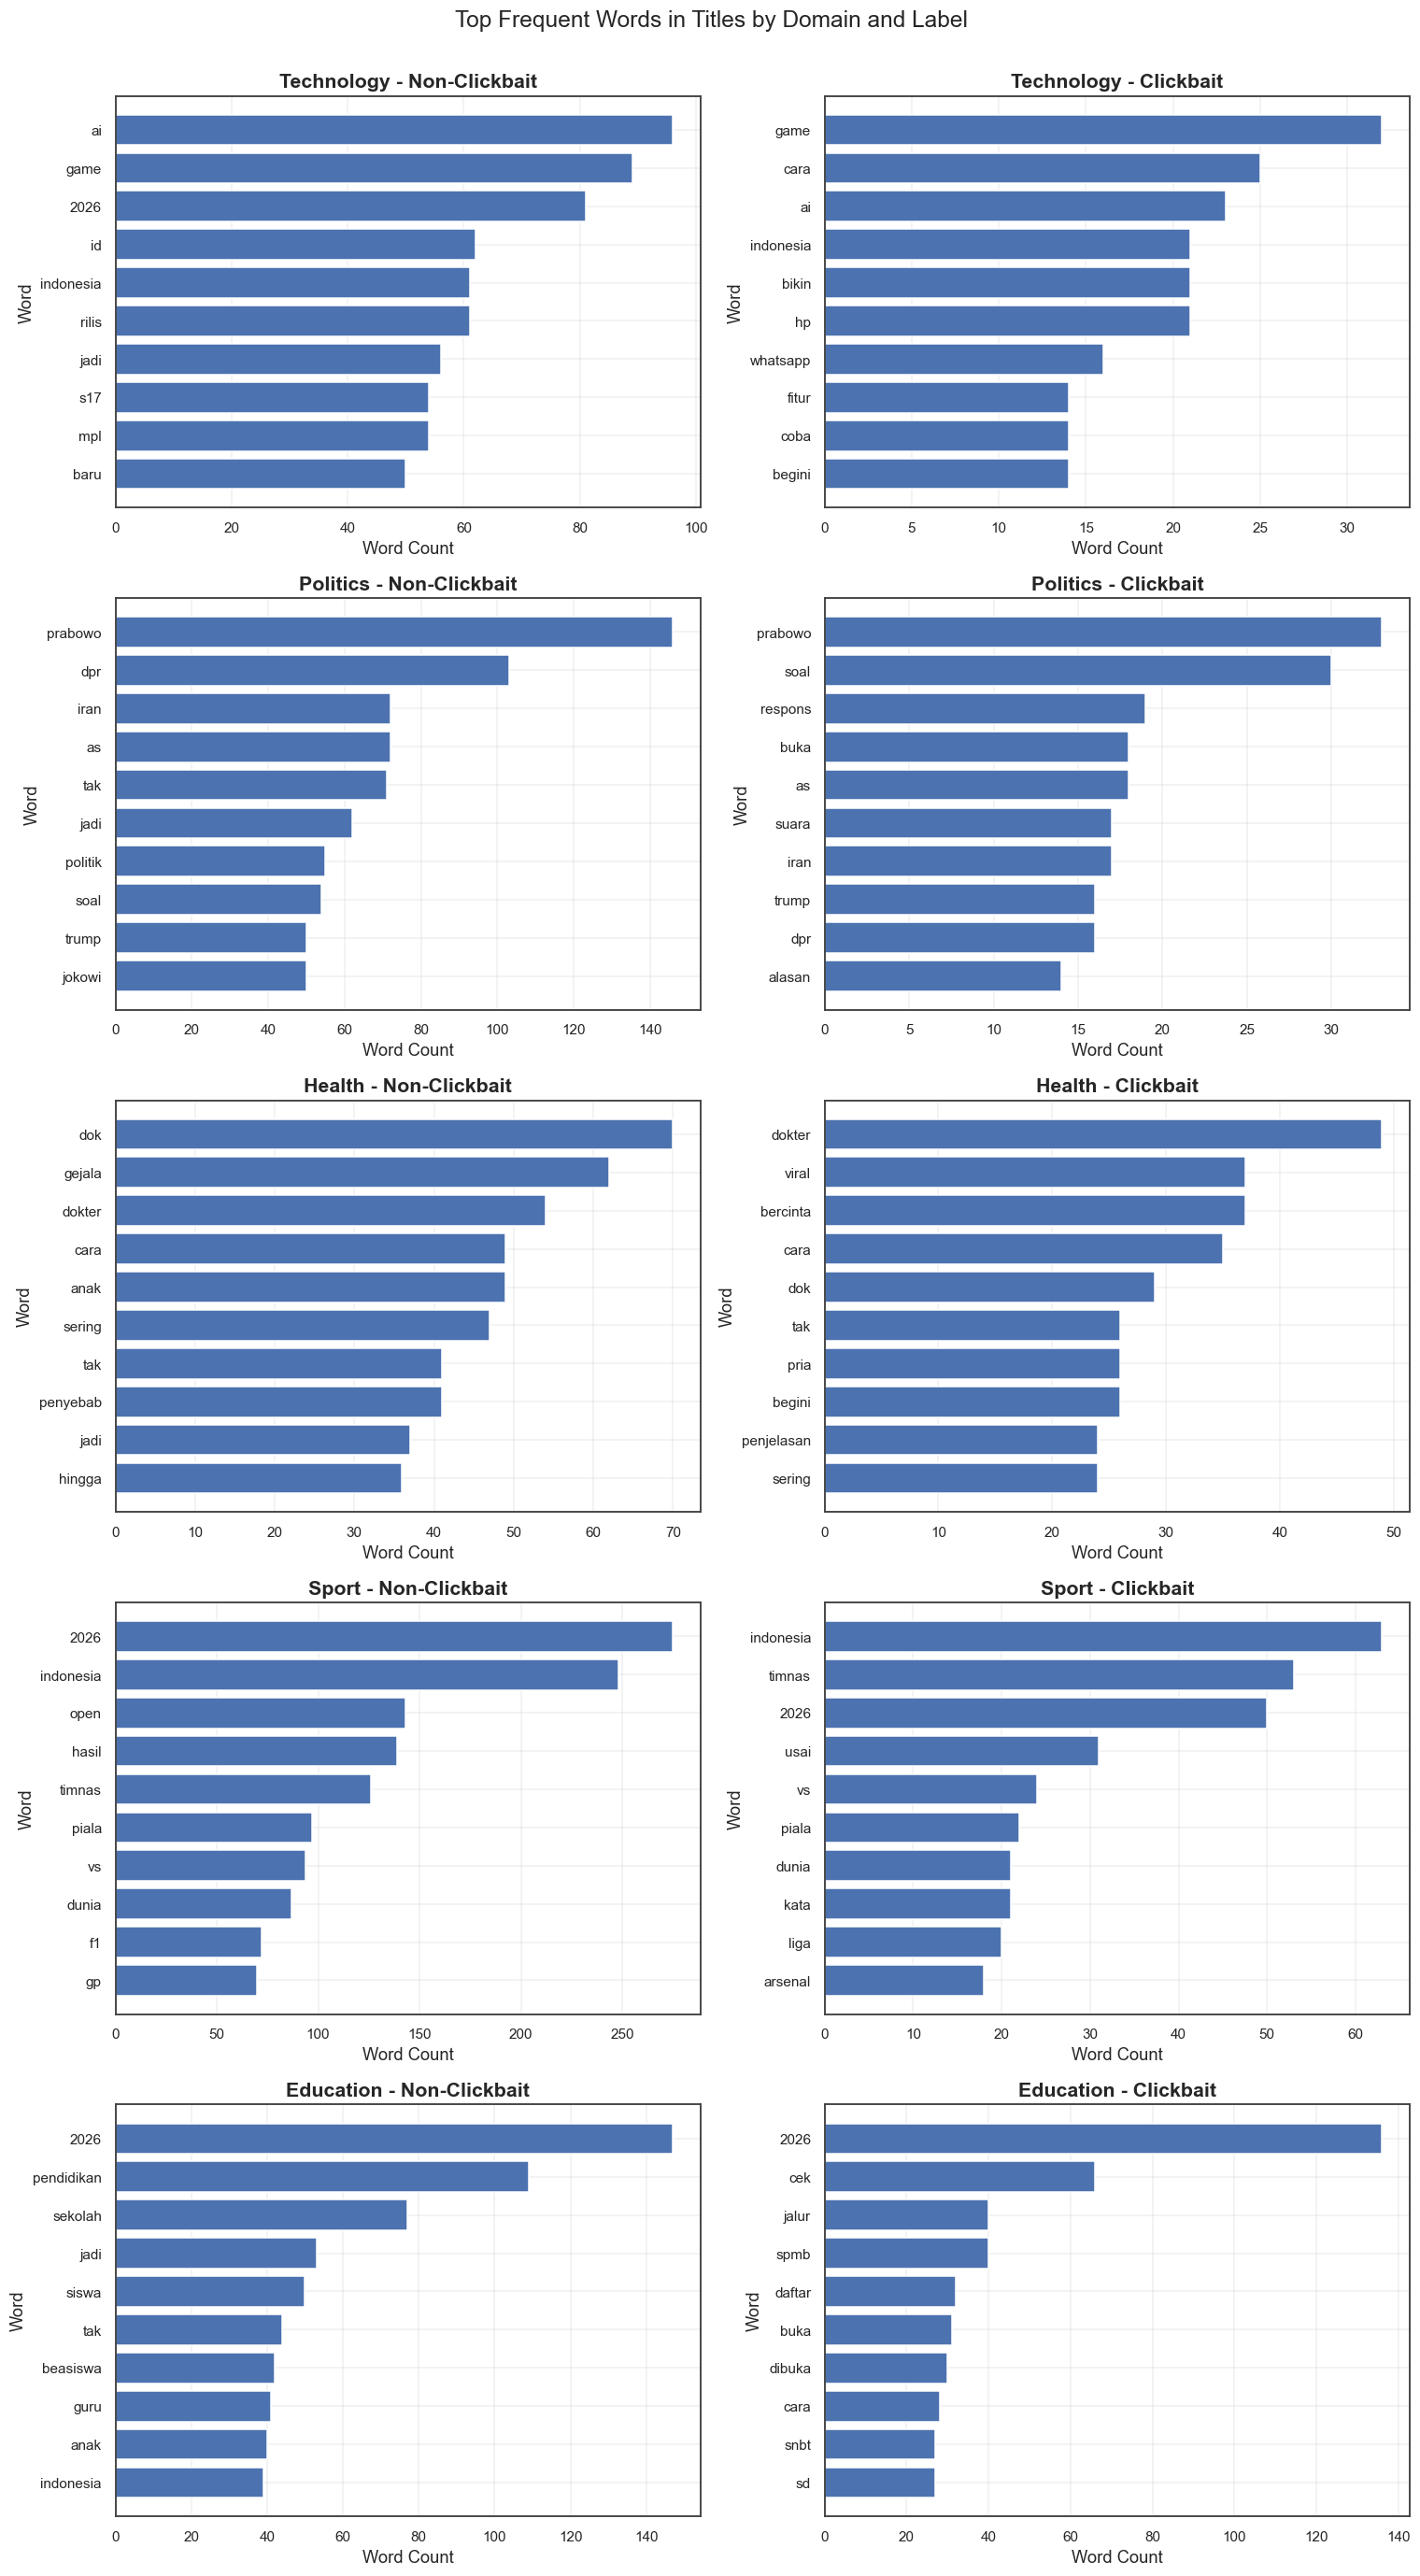

In [20]:
# =========================
# TOP FREQUENT WORDS BY DOMAIN AND LABEL
# =========================

from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Stopwords used only for this analysis
stopwords = StopWordRemoverFactory().get_stop_words()
domains = DOMAINS

fig, axes = plt.subplots(
    nrows=len(domains),
    ncols=2,
    figsize=(14, 5 * len(domains))
)

for row, domain in enumerate(domains):
    df = datasets[domain]

    for col, label in enumerate([0, 1]):
        ax = axes[row, col]
        # Select titles for this label
        titles = df[
            df['Label'] == label
        ]['title'].astype(str)

        # Count words after removing stopwords
        vectorizer = CountVectorizer(
            max_features=10,
            stop_words=stopwords
        )

        X = vectorizer.fit_transform(titles)

        word_counts = np.sum(X.toarray(), axis=0)
        words = vectorizer.get_feature_names_out()

        top_words = pd.DataFrame({
            'word': words,
            'count': word_counts
        })

        top_words = top_words.sort_values(
            by='count',
            ascending=True
        )

        # Plot
        ax.barh(
            top_words['word'],
            top_words['count']
        )
        ax.set_title(
            f'{domain} - {LABEL_NAMES[label]}'
        )
        ax.set_xlabel('Word Count')
        ax.set_ylabel('Word')

# Overall title
fig.suptitle(
    'Top Frequent Words in Titles by Domain and Label',
    fontsize=16,
    y=1.002
)

plt.tight_layout()
plt.show()

### Feature Correlation Matrix

            title_len  Domain_enc  Source_enc  Label_num
title_len    1.000000   -0.119991    0.214527   0.052103
Domain_enc  -0.119991    1.000000   -0.270636  -0.121223
Source_enc   0.214527   -0.270636    1.000000  -0.048914
Label_num    0.052103   -0.121223   -0.048914   1.000000


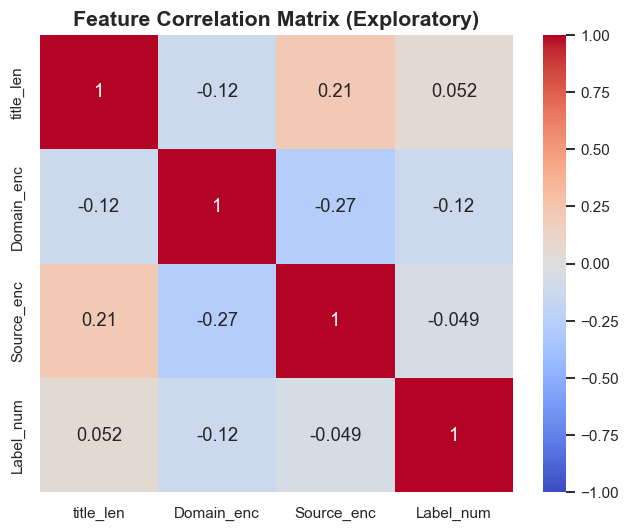

In [21]:
from sklearn.preprocessing import LabelEncoder

feature_df = pd.concat(
    [d.assign(Domain=category) for category, d in datasets.items()],
    ignore_index=True,
)

# Numeric features (derived from feature_df, so lengths always match)
feature_df["title_len"] = (
    feature_df["title"].astype(str).apply(lambda x: len(x.split()))
)
feature_df["Label_num"] = pd.to_numeric(feature_df["Label"], errors="coerce")

# Encode categorical columns that actually exist
le_domain = LabelEncoder()
feature_df["Domain_enc"] = le_domain.fit_transform(feature_df["Domain"])

le_source = LabelEncoder()
feature_df["Source_enc"] = le_source.fit_transform(feature_df["source"].astype(str))

# Correlation on aligned, equal-length columns
corr = feature_df[["title_len", "Domain_enc", "Source_enc", "Label_num"]].corr()
print(corr)

# =============PLOT=========================
plt.figure(figsize=(6, 5))

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Feature Correlation Matrix (Exploratory)")
plt.tight_layout()
plt.show()

### Pearson Correlation & Cramér's V Association Matrix

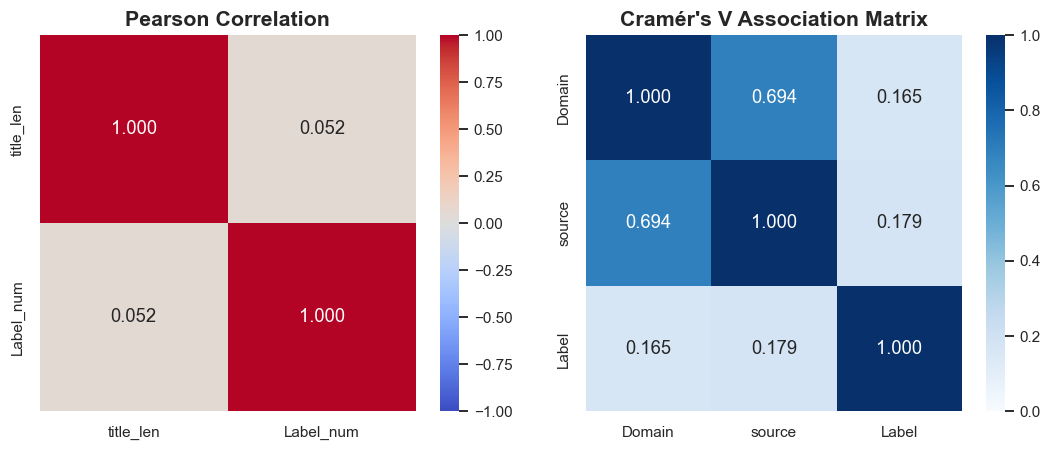

In [ ]:
from scipy.stats import chi2_contingency

# Build ONE combined frame so features have consistent length and the
# categorical columns actually exist. The raw CSVs have no 'domain' column
# (only per-file category), so we attach 'Domain' from the datasets keys.
assoc_df = pd.concat(
    [d.assign(Domain=category) for category, d in datasets.items()],
    ignore_index=True,
)
assoc_df['title_len'] = assoc_df['title'].astype(str).apply(lambda x: len(x.split()))
assoc_df['Label_num'] = pd.to_numeric(assoc_df['Label'], errors='coerce')


# =========================
# Cramér's V function
# =========================
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape

    denom = n * min(r - 1, k - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else 0.0


# =========================
# Calculate Pearson
# =========================
pearson_corr = assoc_df[['title_len', 'Label_num']].corr()


# =========================
# Calculate Cramér's V
# =========================
cols = ['Domain', 'source', 'Label']

cramers_matrix = pd.DataFrame(
    index=cols,
    columns=cols,
    dtype=float
)

for col1 in cols:
    for col2 in cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(
                assoc_df[col1],
                assoc_df[col2]
            )


# =========================
# Plot side by side
# =========================
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

# Pearson
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0]
)
axes[0].set_title('Pearson Correlation')

# Cramér's V
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    square=True,
    ax=axes[1]
)
axes[1].set_title("Cramér's V Association Matrix")

plt.tight_layout()
plt.show()

### Unique Vocabulary for Each Domain

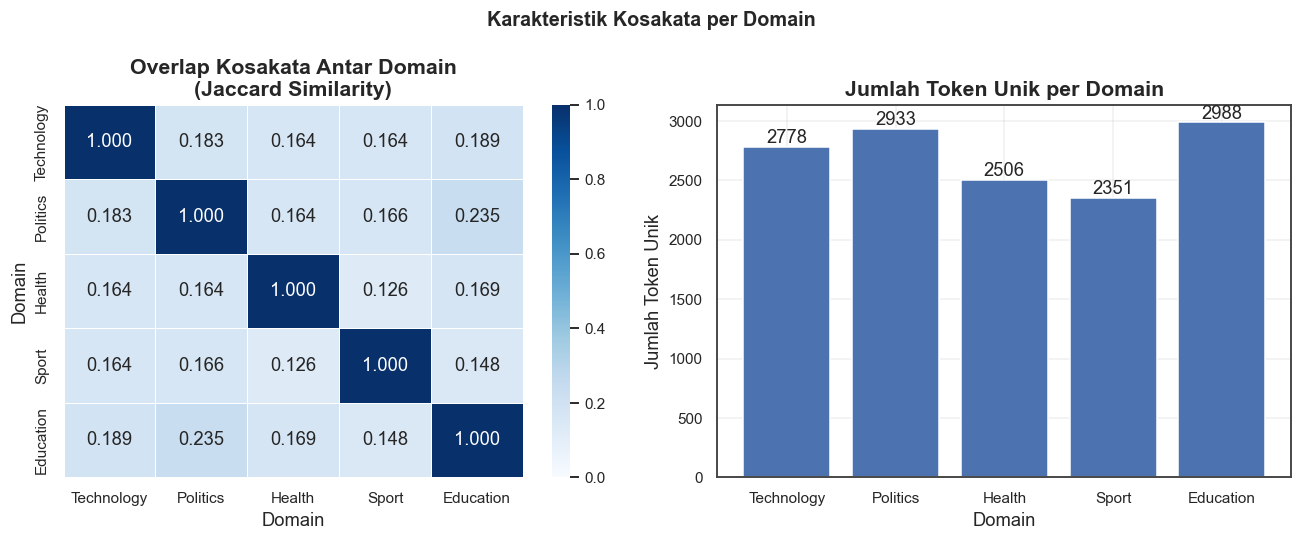

In [23]:
# ═══════════════════════════════════════════════════════════
# VISUALISASI 6 — Kosakata Antar Domain
# ═══════════════════════════════════════════════════════════

import re

# Tokenize titles
def tokenize(text):
    return set(
        re.sub(r"[^a-zA-Z\s]", "", str(text).lower()).split()
    )


# Get unique vocabulary for each domain
domain_vocab = {}

for domain in domains:
    titles = feature_df[feature_df["Domain"] == domain]["title"]
    vocab = set()

    for title in titles:
        vocab.update(tokenize(title))

    domain_vocab[domain] = vocab


# Calculate Jaccard similarity
jaccard_matrix = pd.DataFrame(
    index=domains,
    columns=domains,
    dtype=float
)

for d1 in domains:
    for d2 in domains:
        vocab1 = domain_vocab[d1]
        vocab2 = domain_vocab[d2]

        union = len(vocab1 | vocab2)
        if union == 0:
            jaccard_matrix.loc[d1, d2] = 0
        else:
            jaccard_matrix.loc[d1, d2] = (
                len(vocab1 & vocab2) / union
            )


# =========================
# PLOT
# =========================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

fig.suptitle(
    "Karakteristik Kosakata per Domain",
    fontsize=13,
    fontweight="bold"
)

# cc heatmap
sns.heatmap(
    jaccard_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title("Overlap Kosakata Antar Domain\n(Jaccard Similarity)")
axes[0].set_xlabel("Domain")
axes[0].set_ylabel("Domain")


# Vocabulary size
vocab_sizes = [
    len(domain_vocab[domain])
    for domain in domains
]

axes[1].bar(
    domains,
    vocab_sizes
)

axes[1].set_title("Jumlah Token Unik per Domain")
axes[1].set_xlabel("Domain")
axes[1].set_ylabel("Jumlah Token Unik")

for i, value in enumerate(vocab_sizes):
    axes[1].text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()

In [24]:
## 7. Comparative Analysis
### 7.1 Dataset Size Comparison

### Dataset Size Comparison

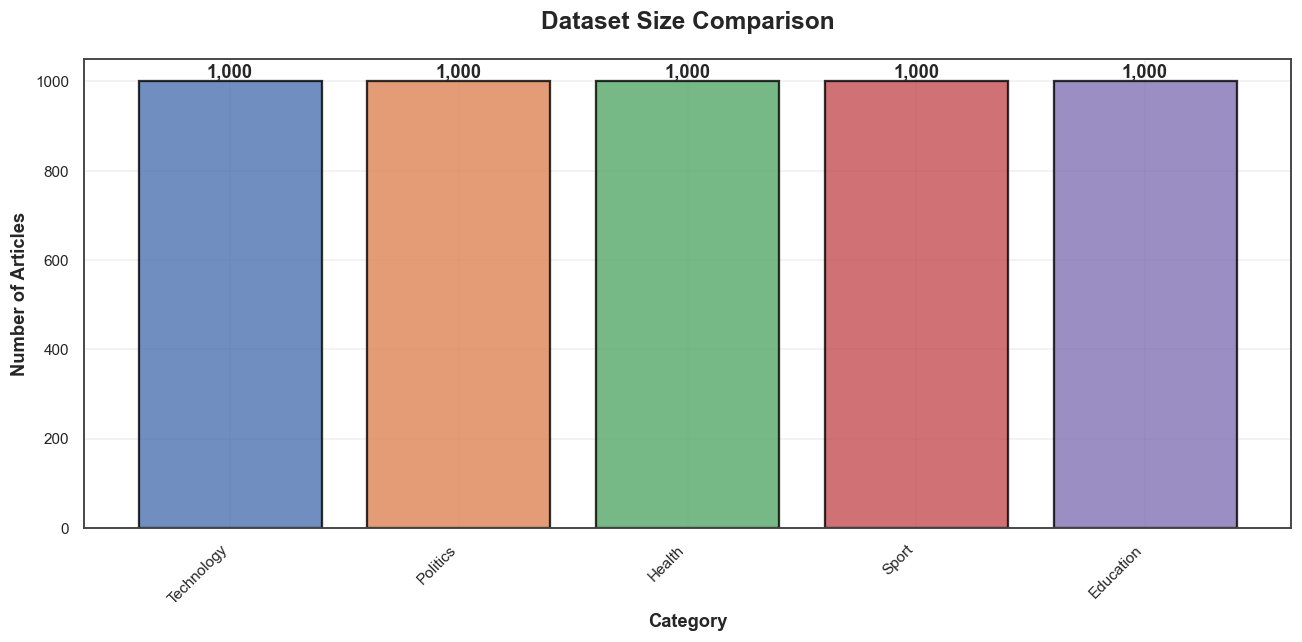


Total articles: 5,000
Average: 1000
Largest: Technology (1,000)
Smallest: Technology (1,000)


In [ ]:
categories = DOMAINS
sizes = [len(datasets[c]) for c in categories]

plt.figure(figsize=(12, 6))
bars = plt.bar(
    categories,
    sizes,
    color=[DOMAIN_COLORS.get(c, "#4C72B0") for c in categories],
    edgecolor="black",
    linewidth=1.5,
    alpha=0.8,
)

plt.title("Dataset Size Comparison", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Category", fontsize=12, fontweight="bold")
plt.ylabel("Number of Articles", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

print(f"\nTotal articles: {sum(sizes):,}")
print(f"Average: {np.mean(sizes):.0f}")
print(f"Largest: {categories[np.argmax(sizes)]} ({max(sizes):,})")
print(f"Smallest: {categories[np.argmin(sizes)]} ({min(sizes):,})")


### 7.3 Source Diversity


Source Diversity Summary:


,Category,Unique Sources,Total Articles,Avg per Source
0,Technology,3,1000,333.3
1,Politics,5,1000,200.0
2,Health,3,1000,333.3
3,Sport,3,1000,333.3
4,Education,3,1000,333.3


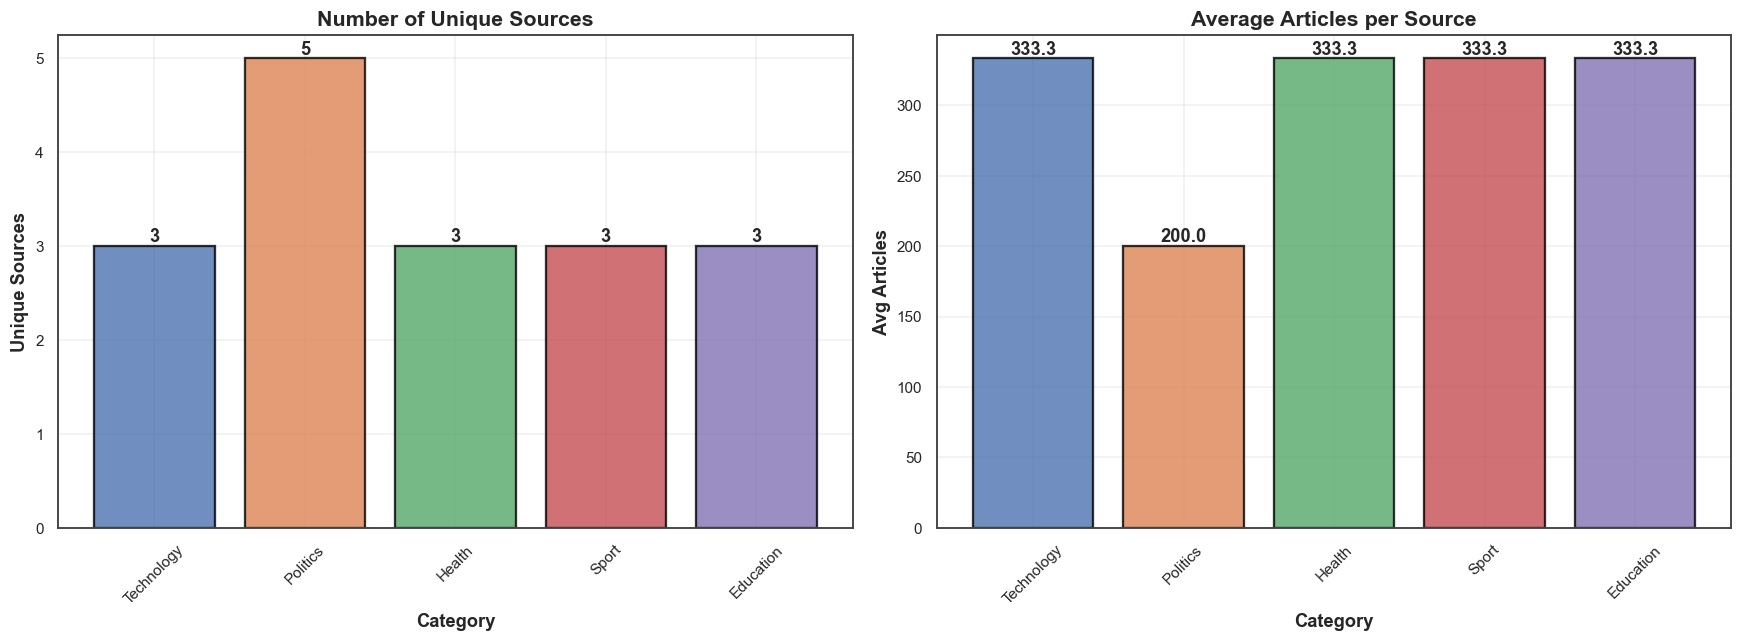

In [26]:
source_diversity = []

for category, df in datasets.items():
    if "source" in df.columns:
        unique_sources = df["source"].nunique()
        total_articles = len(df)

        source_diversity.append(
            {
                "Category": category,
                "Unique Sources": unique_sources,
                "Total Articles": total_articles,
                "Avg per Source": round(
                    total_articles / unique_sources, 1
                )
                if unique_sources > 0
                else 0,
            }
        )

if source_diversity:
    diversity_df = pd.DataFrame(source_diversity)
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(16, 6)
    )

    ax1.bar(
        diversity_df["Category"],
        diversity_df["Unique Sources"],
        color=[
            DOMAIN_COLORS.get(c, "#4C72B0")
            for c in diversity_df["Category"]
        ],
        edgecolor="black",
        linewidth=1.5,
        alpha=0.8,
    )

    ax1.set_title(
        "Number of Unique Sources",
        fontsize=14,
        fontweight="bold"
    )

    ax1.set_xlabel(
        "Category",
        fontweight="bold"
    )

    ax1.set_ylabel(
        "Unique Sources",
        fontweight="bold"
    )

    ax1.tick_params(
        axis="x",
        rotation=45
    )

    ax1.grid(
        axis="y",
        alpha=0.3
    )

    for i, v in enumerate(diversity_df["Unique Sources"]):
        ax1.text(
            i,
            v,
            str(v),
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    ax2.bar(
        diversity_df["Category"],
        diversity_df["Avg per Source"],
        color=[
            DOMAIN_COLORS.get(c, "#4C72B0")
            for c in diversity_df["Category"]
        ],
        edgecolor="black",
        linewidth=1.5,
        alpha=0.8,
    )

    ax2.set_title(
        "Average Articles per Source",
        fontsize=14,
        fontweight="bold"
    )

    ax2.set_xlabel(
        "Category",
        fontweight="bold"
    )

    ax2.set_ylabel(
        "Avg Articles",
        fontweight="bold"
    )

    ax2.tick_params(
        axis="x",
        rotation=45
    )

    ax2.grid(
        axis="y",
        alpha=0.3
    )

    for i, v in enumerate(diversity_df["Avg per Source"]):
        ax2.text(
            i,
            v,
            f"{v:.1f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    print("\nSource Diversity Summary:")
    display(diversity_df)
    
    plt.tight_layout()
    plt.show()

### 7.4 Data Quality Comparison

In [27]:
# quality_data = []
# for category, df in datasets.items():
#     quality_data.append({
#         'Category': category,
#         'Total Rows': len(df),
#         'Missing Values': df.isnull().sum().sum(),
#         'Duplicate Rows': df.duplicated().sum(),
#         'Duplicate Titles': df['title'].duplicated().sum() if 'title' in df.columns else 0,
#         'Duplicate URLs': df['url'].duplicated().sum() if 'url' in df.columns else 0
#     })

# quality_df = pd.DataFrame(quality_data)
# print("\nData Quality Comparison:")
# display(quality_df)

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# axes[0].bar(quality_df['Category'], quality_df['Missing Values'],
#            color=LABEL_COLORS['Clickbait'], edgecolor='black', alpha=0.8)
# axes[0].set_title('Missing Values', fontweight='bold')
# axes[0].set_ylabel('Count')
# axes[0].tick_params(axis='x', rotation=45)
# axes[0].grid(axis='y', alpha=0.3)

# axes[1].bar(quality_df['Category'], quality_df['Duplicate Titles'],
#            color=LABEL_COLORS['Non-Clickbait'], edgecolor='black', alpha=0.8)
# axes[1].set_title('Duplicate Titles', fontweight='bold')
# axes[1].set_ylabel('Count')
# axes[1].tick_params(axis='x', rotation=45)
# axes[1].grid(axis='y', alpha=0.3)

# axes[2].bar(quality_df['Category'], quality_df['Duplicate URLs'],
#            color=sns.color_palette("deep")[2], edgecolor='black', alpha=0.8)
# axes[2].set_title('Duplicate URLs', fontweight='bold')
# axes[2].set_ylabel('Count')
# axes[2].tick_params(axis='x', rotation=45)
# axes[2].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

## 8. Summary and Conclusions

In [28]:
print("EXPLORATORY DATA ANALYSIS SUMMARY")

total_articles = sum(len(df) for df in datasets.values())
print(f"\nTotal Articles Analyzed: {total_articles:,}")
print(f"Number of Categories: {len(datasets)}")
print(f"Categories: {', '.join(datasets.keys())}")

print("\nKey Findings:")
for category, df in datasets.items():
    print(f"\n{category}:")
    print(f"  - Articles: {len(df):,}")
    if 'source' in df.columns:
        print(f"  - Sources: {df['source'].nunique()}")
    if 'Label' in df.columns:
        label_counts = df['Label'].value_counts()
        if len(label_counts) == 2:
            ratio = label_counts.max() / label_counts.min()
            print(f"  - Class Balance: {ratio:.2f}:1 ({'Balanced' if ratio < 1.5 else 'Imbalanced'})")
    if 'title' in df.columns:
        avg_length = df['title'].astype(str).str.len().mean()
        print(f"  - Avg Title Length: {avg_length:.0f} characters")

EXPLORATORY DATA ANALYSIS SUMMARY

Total Articles Analyzed: 5,000
Number of Categories: 5
Categories: Technology, Politics, Health, Sport, Education

Key Findings:

Technology:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 3.39:1 (Imbalanced)
  - Avg Title Length: 63 characters

Politics:
  - Articles: 1,000
  - Sources: 5
  - Class Balance: 4.35:1 (Imbalanced)
  - Avg Title Length: 66 characters

Health:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 1.66:1 (Imbalanced)
  - Avg Title Length: 69 characters

Sport:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 3.22:1 (Imbalanced)
  - Avg Title Length: 66 characters

Education:
  - Articles: 1,000
  - Sources: 3
  - Class Balance: 1.86:1 (Imbalanced)
  - Avg Title Length: 73 characters


## 9. Deep Exploratory Data Analysis (Clickbait Detection)

Comprehensive, report-ready EDA across the five domains. Rules followed here:

1. **Every table is immediately paired with a matching visualization** of the same data.
2. **Varied, annotated chart types** (donut, bar, stacked bar, box, violin, histogram); bar/pie charts carry counts/percentages directly.
3. **One unified visual style** (palette, fonts, titles, axis labels) set globally in the setup cell below.

**Unified palette** — Label colors (fixed meaning everywhere): `Non-Clickbait = #4C72B0`, `Clickbait = #DD8452`; Domain colors: seaborn `deep`.

### 9.0 Build Combined Frame (all_df)

Section 9 relies on the unified style, palette and helpers defined in the top
Setup cell (LABEL_COLORS, LABEL_NAMES, DOMAINS, annotate_bars, annotate_barh,
show_table). This cell builds the single combined dataframe `all_df` used by
every Section 9 step. Run the top Setup cell and the Load Datasets cell first.

In [29]:
# Combined dataframe used by every Section 9 step (guarantees equal lengths)
all_df = pd.concat(
    [d.assign(Domain=category) for category, d in datasets.items()],
    ignore_index=True,
)
all_df["Label"] = pd.to_numeric(all_df["Label"], errors="coerce").astype("Int64")
all_df["Label_Name"] = all_df["Label"].map(LABEL_NAMES)
all_df["title"] = all_df["title"].astype(str)
all_df["char_len"] = all_df["title"].str.len()
all_df["word_len"] = all_df["title"].str.split().apply(len)

print("Combined dataset:", all_df.shape)
print("Domains:", DOMAINS)

Combined dataset: (5000, 14)
Domains: ['Technology', 'Politics', 'Health', 'Sport', 'Education']


### 9.5 Title-Length (Characters & Words)

Descriptive statistics for title length, then box plots, violin plots, and histograms to expose extremely short/long titles (outliers) overall, by domain, and by label.


Title Length Descriptive Statistics (overall)


,Characters,Words
count,5000.00,5000.00
mean,67.50,10.34
std,11.07,1.87
min,27.00,5.00
Q1,61.00,9.00
median,68.00,10.00
Q3,74.00,12.00
max,106.00,18.00



Title Length Outliers via 1.5 x IQR rule


,Metric,Lower Bound,Upper Bound,Outliers (n),Outliers (%)
0,Characters,41.5,93.5,146,2.92
1,Words,4.5,16.5,3,0.06


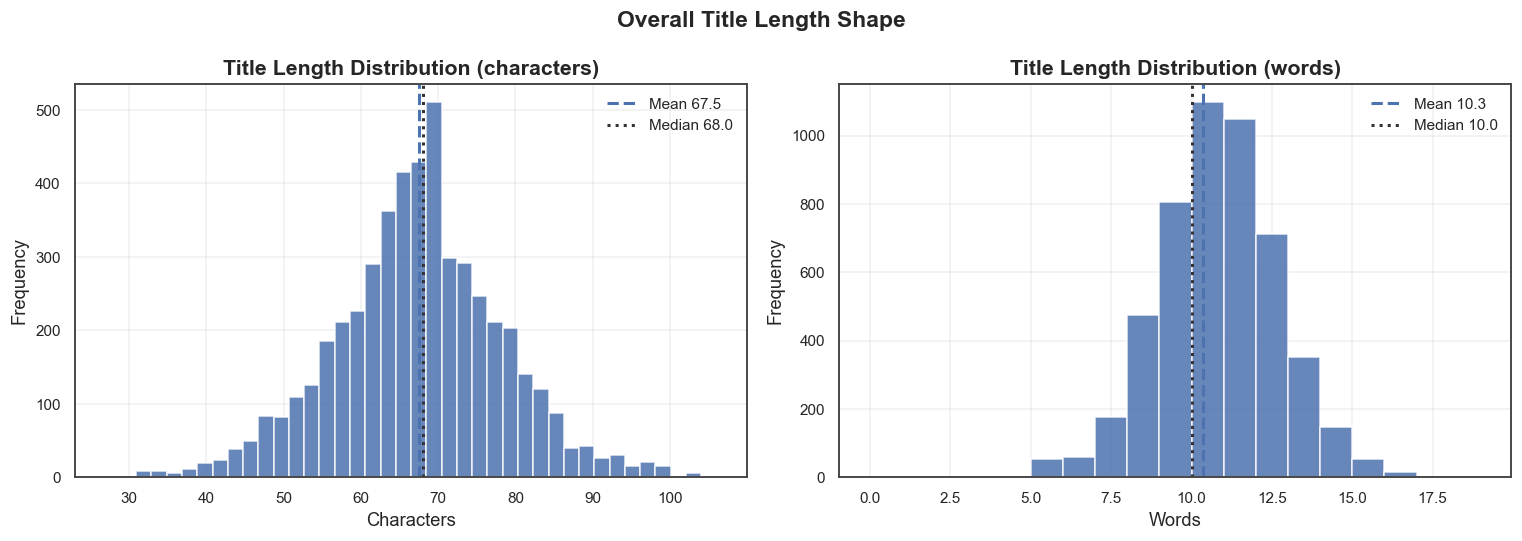

In [30]:
# =============== DESCRIPTIVE STATISTICS ===============

def describe_len(col):
    s = all_df[col]

    return pd.Series({
        "count": s.count(),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "Q1": s.quantile(0.25),
        "median": s.median(),
        "Q3": s.quantile(0.75),
        "max": s.max()
    })


len_stats = pd.DataFrame({
    "Characters": describe_len("char_len"),
    "Words": describe_len("word_len")
}).round(2)

show_table(
    len_stats,
    "Title Length Descriptive Statistics (overall)"
)


# =============== OUTLIERS ===============
outlier_data = []

for name, col in [("Characters", "char_len"), ("Words", "word_len")]:
    q1, q3 = all_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (all_df[col] < lower) |
        (all_df[col] > upper)
    ).sum()

    outlier_data.append({
        "Metric": name,
        "Lower Bound": round(max(lower, 0), 1),
        "Upper Bound": round(upper, 1),
        "Outliers (n)": int(outliers),
        "Outliers (%)": round(outliers / len(all_df) * 100, 2)
    })


outlier_tbl = pd.DataFrame(outlier_data)

show_table(
    outlier_tbl,
    "Title Length Outliers via 1.5 x IQR rule"
)


# =============== VISUALIZATION ===============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = [
    ("char_len", "Characters", 40),
    ("word_len", "Words", range(0, int(all_df["word_len"].max()) + 2))
]

for ax, (col, label, bins) in zip(axes, metrics):
    ax.hist(
        all_df[col],
        bins=bins,
        edgecolor="white",
        alpha=0.85
    )

    mean = all_df[col].mean()
    median = all_df[col].median()

    ax.axvline(
        mean,
        ls="--",
        lw=2,
        label=f"Mean {mean:.1f}"
    )

    ax.axvline(
        median,
        color="#333333",
        ls=":",
        lw=2,
        label=f"Median {median:.1f}"
    )

    ax.set_title(f"Title Length Distribution ({label.lower()})")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.legend(frameon=False)


fig.suptitle(
    "Overall Title Length Shape",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

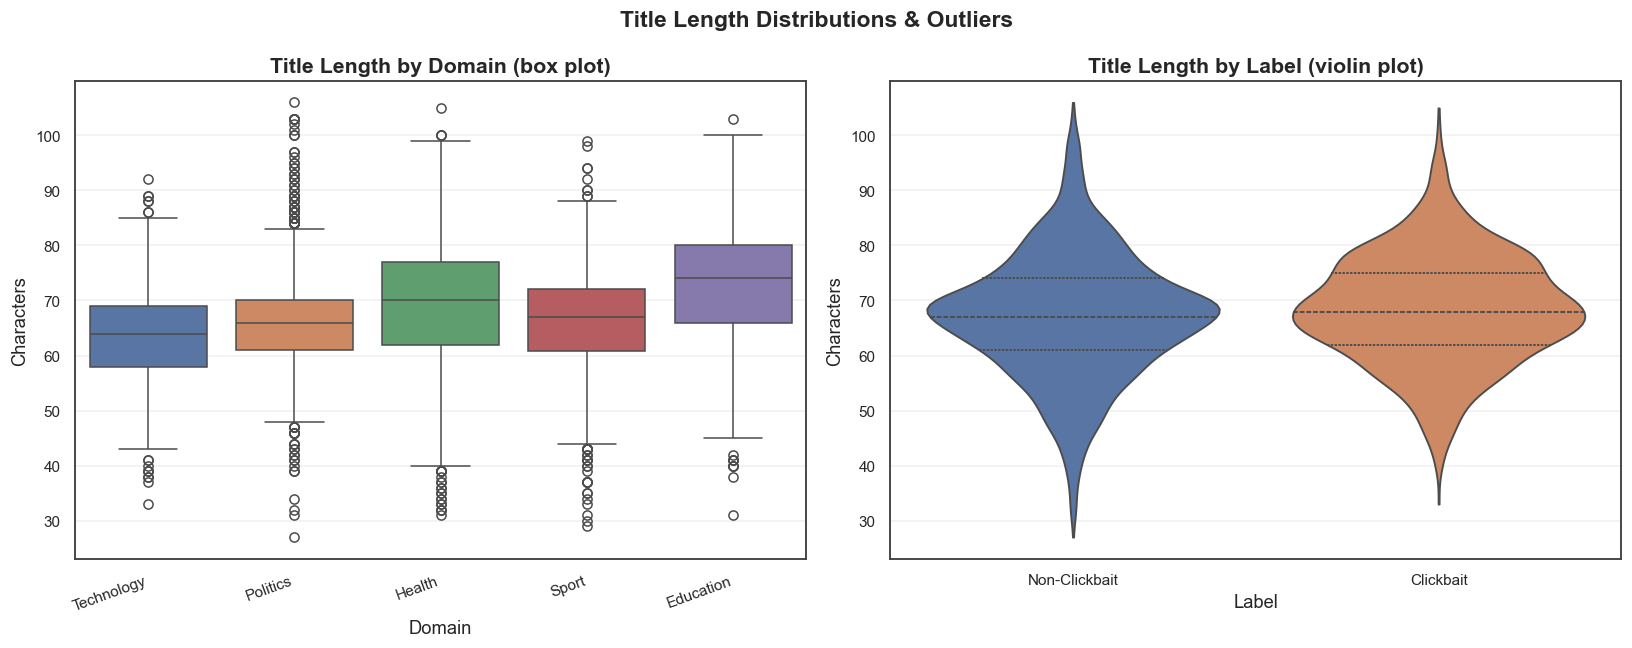

In [31]:
# ---------------- VISUALIZATION: box plots by domain, violin by label ----------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot of character length by domain (outliers visible as points)
sns.boxplot(data=all_df, x="Domain", y="char_len", order=DOMAINS,
            palette=DOMAIN_COLORS, ax=axes[0])
axes[0].set_title("Title Length by Domain (box plot)")
axes[0].set_xlabel("Domain"); axes[0].set_ylabel("Characters")
axes[0].set_xticklabels(DOMAINS, rotation=20, ha="right")

# Violin plot of character length by label (distribution shape + spread)
sns.violinplot(data=all_df, x="Label_Name", y="char_len", order=LABEL_ORDER,
               palette=LABEL_COLORS, cut=0, inner="quartile", ax=axes[1])
axes[1].set_title("Title Length by Label (violin plot)")
axes[1].set_xlabel("Label"); axes[1].set_ylabel("Characters")

fig.suptitle("Title Length Distributions & Outliers", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# # ---------------- VISUALIZATION: word length by domain split by label ----------------
# fig, ax = plt.subplots(figsize=(13, 6))
# sns.boxplot(data=all_df, x="Domain", y="word_len", hue="Label_Name",
#             order=DOMAINS, hue_order=LABEL_ORDER, palette=LABEL_COLORS, ax=ax)
# ax.set_title("Title Word Count by Domain and Label (box plot)")
# ax.set_xlabel("Domain"); ax.set_ylabel("Words")
# ax.set_xticklabels(DOMAINS, rotation=20, ha="right")
# ax.legend(title="Label", frameon=False)
# plt.tight_layout()
# plt.show()

### 4.4 Title Length Statistics

==========Title Statistics==========


,Domain,Mean_Characters,Median_Characters,Min_Characters,Max_Characters,Std_Characters,Mean_Words,Median_Words,Min_Words,Max_Words,Std_Words
0,Education,72.97,74.0,31,103,10.95,10.92,11.0,5,18,1.81
1,Health,68.75,70.0,31,105,12.61,10.35,11.0,5,16,2.17
2,Politics,66.47,66.0,27,106,10.37,10.12,10.0,5,17,1.71
3,Sport,65.94,67.0,29,99,9.91,10.06,10.0,5,15,1.72
4,Technology,63.35,64.0,33,92,8.76,10.26,10.0,5,16,1.79


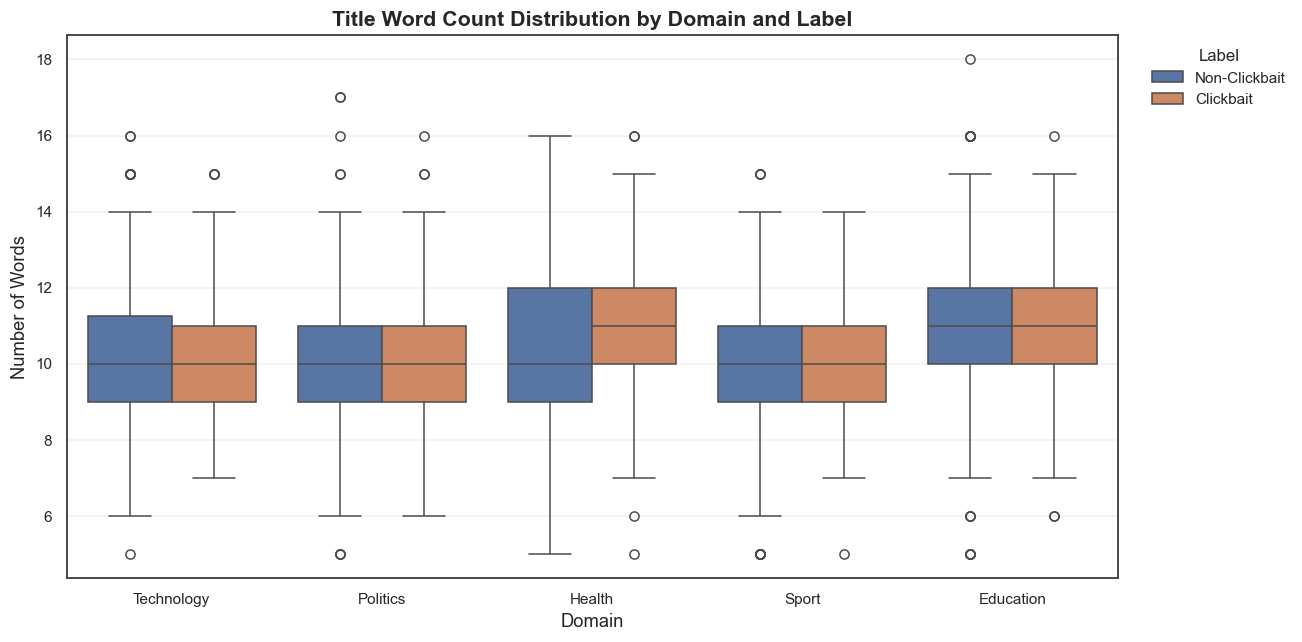

In [32]:
title_data = []

print("==========Title Statistics==========")

for category, df in datasets.items():
    if 'title' not in df.columns:
        continue

    # Exclude missing titles
    valid_df = df.dropna(subset=['title']).copy()

    for _, row in valid_df.iterrows():
        title = str(row['title'])

        title_data.append({
            'Domain': category,
            'Label': row['Label'] if 'Label' in valid_df.columns else None,
            'Title_Length': len(title),
            'Word_Count': len(title.split())
        })

title_df = pd.DataFrame(title_data)

# ===============STATISTICS===============
stats_df = (
    title_df
    .groupby('Domain')
    .agg(
        Mean_Characters=('Title_Length', 'mean'),
        Median_Characters=('Title_Length', 'median'),
        Min_Characters=('Title_Length', 'min'),
        Max_Characters=('Title_Length', 'max'),
        Std_Characters=('Title_Length', 'std'),

        Mean_Words=('Word_Count', 'mean'),
        Median_Words=('Word_Count', 'median'),
        Min_Words=('Word_Count', 'min'),
        Max_Words=('Word_Count', 'max'),
        Std_Words=('Word_Count', 'std')
    )
    .round(2)
    .reset_index()
)

display(stats_df)


# ===============PLOT: WORD COUNT===============
plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=title_df,
    x='Domain',
    y='Word_Count',
    hue='Label',
    width=0.8,
    palette=LABEL_COLORS_NUM
)

plt.title('Title Word Count Distribution by Domain and Label')
plt.xlabel('Domain')
plt.ylabel('Number of Words')

handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    LABEL_ORDER,
    title='Label',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

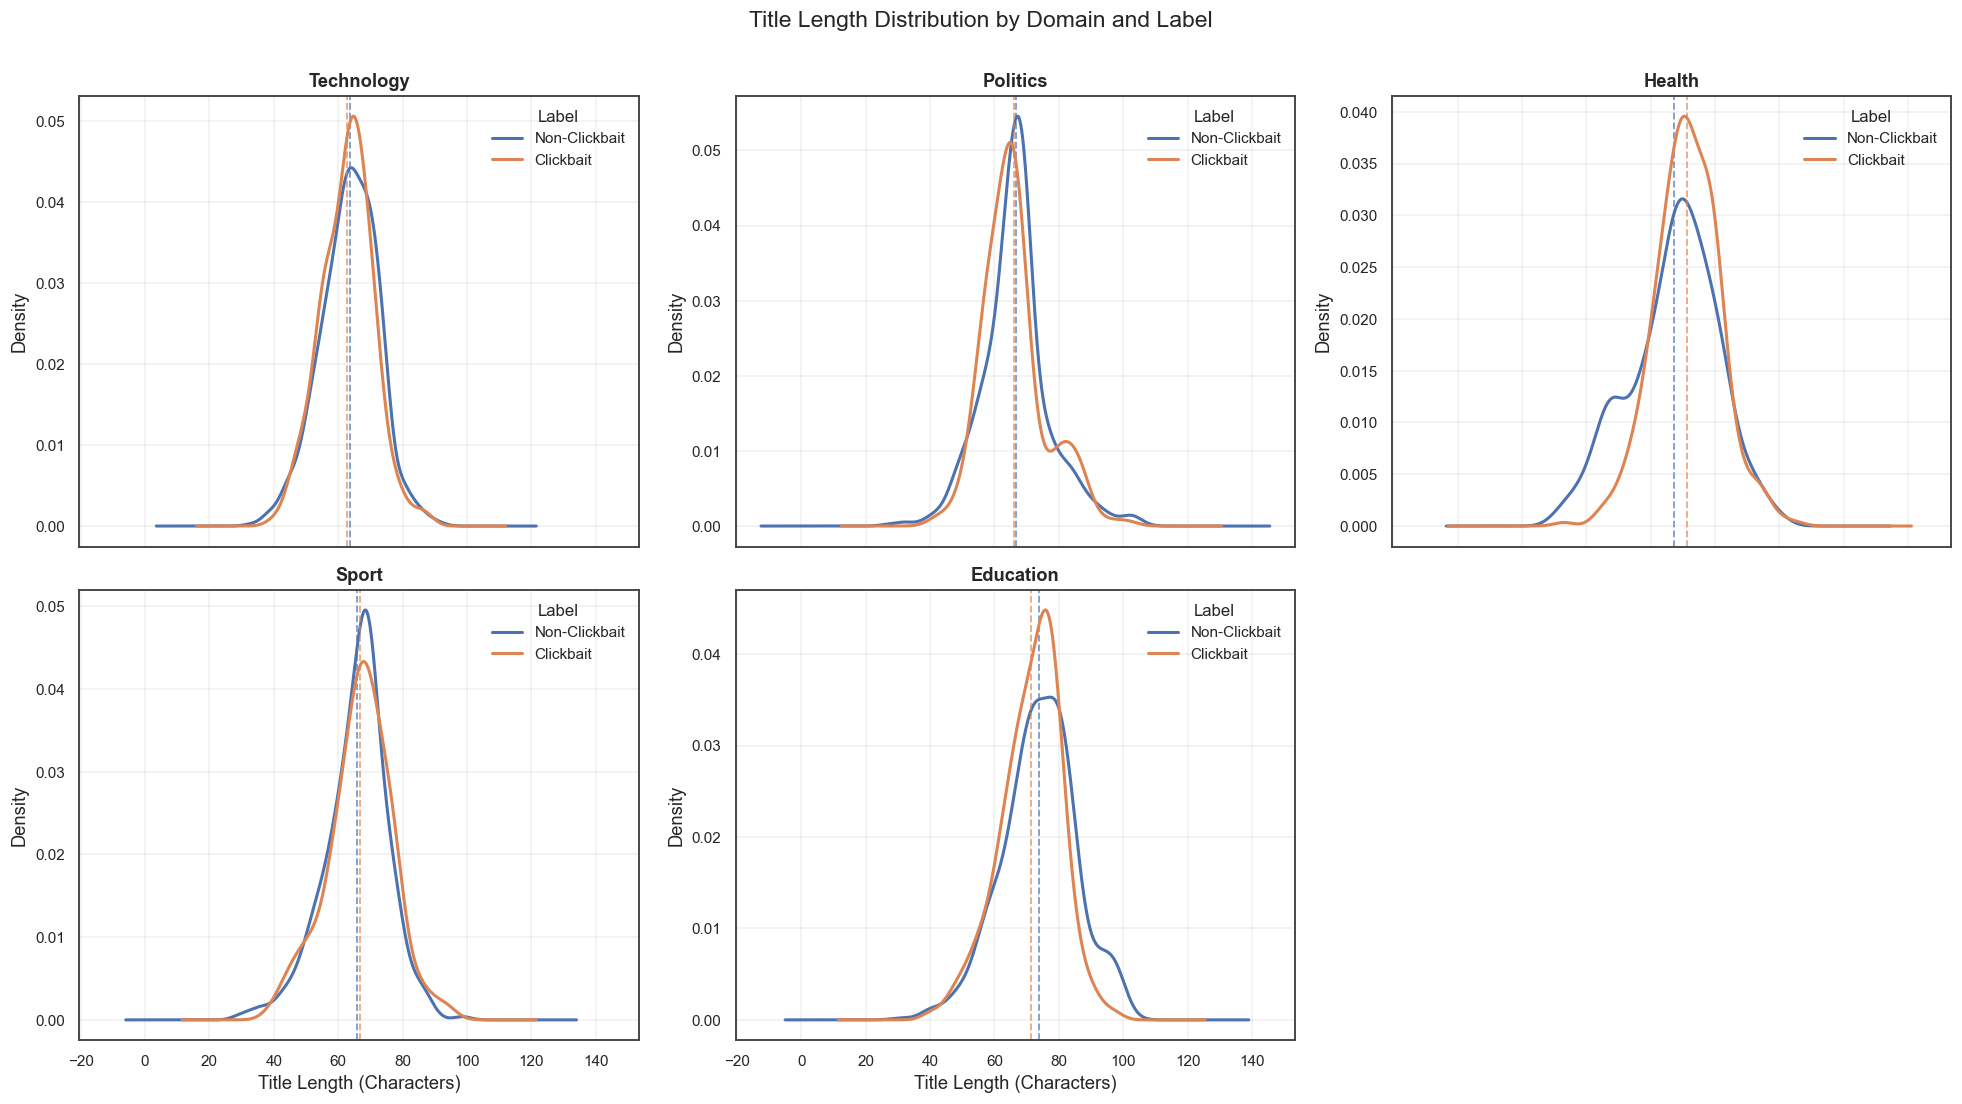

In [33]:
domains = DOMAINS

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18,10),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, domain in zip(axes, domains):
    domain_df = title_df[title_df['Domain'] == domain]

    for label, color in LABEL_COLORS_NUM.items():
        subset = domain_df[
            domain_df['Label'] == label
        ]['Title_Length'].dropna()

        if len(subset) < 2:
            continue

        subset.plot.kde(
            ax=ax,
            color=color,
            label=LABEL_NAMES[label],
            linewidth=2
        )

        ax.axvline(
            subset.mean(),
            color=color,
            linestyle='--',
            linewidth=1.2,
            alpha=0.7
        )

    ax.set_title(domain, fontsize=12)
    ax.set_xlabel('Title Length (Characters)')
    ax.set_ylabel('Density')
    ax.legend(title='Label', frameon=False)

# Hide the unused sixth subplot
for ax in axes[len(domains):]:
    ax.set_visible(False)

fig.suptitle(
    'Title Length Distribution by Domain and Label',
    fontsize=15,
    y=1.002
)

plt.tight_layout()
plt.show()

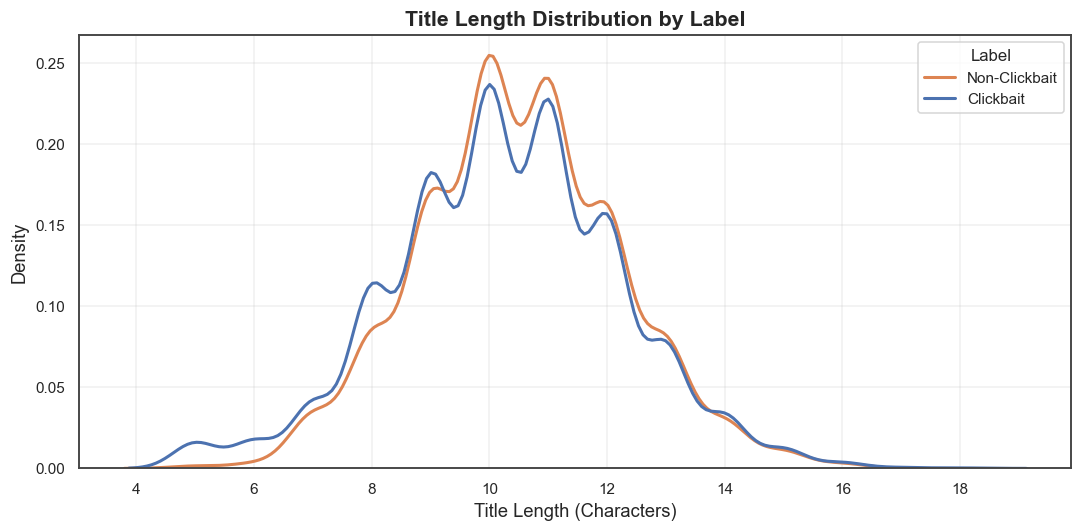

In [34]:
# =========================
# TITLE LENGTH DISTRIBUTION
# =========================

plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=feature_df,
    x='title_len',
    hue='Label',
    common_norm=False,
    fill=False,
    linewidth=2
)

plt.title('Title Length Distribution by Label')
plt.xlabel('Title Length (Characters)')
plt.ylabel('Density')

plt.legend(
    title='Label',
    labels=LABEL_ORDER
)

plt.tight_layout()
plt.show()